# 🧬 GGN-GO: Protein Function Prediction on CAFA-5 Data

This notebook uses the **GGN-GO** (GVP-GNN for Gene Ontology) neural network
to predict protein functions on the **CAFA-5** dataset.

## Architecture Overview

GGN-GO combines:
- **GVP (Geometric Vector Perceptron)** layers to encode 3D protein structure graphs
- **ProtTrans** (T5-XL) and **ESM2** language model embeddings as node features
- **DSSP** secondary structure features
- **GraphMultisetTransformer** pooling for graph-level readout
- **Contrastive learning** (NT-Xent) with node perturbation for regularization
- **MLP readout** head with Sigmoid for multi-label GO term classification

### Node Features (per residue, 2324-d total)
| Feature | Dimensions |
|---------|-----------|
| Dihedral angles (sin/cos) | 6 |
| ProtTrans (T5-XL-UniRef50) | 1024 |
| ESM2 (esm2_t33_650M) | 1280 |
| DSSP (SS + ASA + angles) | 14 |

### References
- GGN-GO: https://github.com/MiJia-ID/GGN-GO
- CAFA-5: Critical Assessment of Functional Annotation
- GVP: Geometric Vector Perceptrons (Jing et al., 2021)

## 1. Configuration

Set the runtime environment and dataset size below.

In [ ]:
# ============================================================
# ⚙ CONFIGURATION — Edit these before running
# ============================================================

# Runtime environment: "colab" or "local"
RUNTIME = "colab"  # @param ["colab", "local"]

# Dataset size: "demo" (small subset, fast) or "full" (all CAFA-5 data, ~41gb)
DATASET_MODE = "full"  # @param ["demo", "full"]

# Number of demo proteins (only used if DATASET_MODE == "demo")
DEMO_TRAIN_SIZE = 200
DEMO_VAL_SIZE = 100

# Training hyperparameters
BATCH_SIZE = 32
MAX_EPOCHS = 100
LEARNING_RATE = 1e-4
USE_CONTRASTIVE = True
CONTRASTIVE_WEIGHT = 0.05

# GO task: "bp" (Biological Process), "mf" (Molecular Function), "cc" (Cellular Component)
TASK = "bp"  # @param ["bp", "mf", "cc"]

# Device
DEVICE = "cuda:0"

# Paths (will be set automatically based on RUNTIME)
import os

if RUNTIME == "colab":
    ROOT_DIR = "/content"
else:
    ROOT_DIR = os.path.expanduser("./ggn_go_workspace")
    os.makedirs(ROOT_DIR, exist_ok=True)

GGN_GO_DIR = os.path.join(ROOT_DIR, "GGN-GO")
DATA_DIR = os.path.join(ROOT_DIR, "cafa_data")
FEATURE_DIR = os.path.join(ROOT_DIR, "features")
MODEL_DIR = os.path.join(ROOT_DIR, "trained_models")
GEARNET_EMBEDS_DIR = os.path.join(ROOT_DIR, "gearnet_embeds")
GGNGO_EMBEDS_DIR = os.path.join(FEATURE_DIR, "ggngo_embeddings")

for d in [DATA_DIR, FEATURE_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Runtime: {RUNTIME}")
print(f"Dataset mode: {DATASET_MODE}")
print(f"Base directory: {ROOT_DIR}")

Runtime: colab
Dataset mode: full
Base directory: /content


## 2. Environment Setup

Check GPU, clone GGN-GO, and install dependencies.

In [ ]:
# Check GPU availability
!nvidia-smi

Sun May  3 15:02:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip -q install -U crcmod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Clone GGN-GO repository
if not os.path.exists(GGN_GO_DIR):
    !git clone https://github.com/MiJia-ID/GGN-GO.git {GGN_GO_DIR}
    print(f"Cloned GGN-GO to {GGN_GO_DIR}")
else:
    print(f"GGN-GO already exists at {GGN_GO_DIR}")

# Show repository structure
!ls -la {GGN_GO_DIR}/Script/

Cloning into '/content/GGN-GO'...
remote: Enumerating objects: 155, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 155 (delta 27), reused 32 (delta 6), pack-reused 85 (from 1)
Receiving objects: 100% (155/155), 387.23 MiB | 39.29 MiB/s, done.
Resolving deltas: 100% (36/36), done.
Updating files: 100% (84/84), done.
Cloned GGN-GO to /content/GGN-GO
total 168
drwxr-xr-x 3 root root  4096 May  3 15:02 .
drwxr-xr-x 8 root root  4096 May  3 15:02 ..
-rw-r--r-- 1 root root   617 May  3 15:02 config.py
-rw-r--r-- 1 root root  2122 May  3 15:02 ESM2.py
-rw-r--r-- 1 root root 15175 May  3 15:02 gvp.py
-rw-r--r-- 1 root root  9884 May  3 15:02 model.py
-rw-r--r-- 1 root root 18095 May  3 15:02 myData.py
-rw-r--r-- 1 root root 15643 May  3 15:02 my_Features.py
-rw-r--r-- 1 root root  4592 May  3 15:02 nt_xent.py
-rw-r--r-- 1 root root 10125 May  3 15:02 pool.py
-rw-r--r-- 1 root root 16397 May  3 15:02 Predictor.py
-rw-r--r-- 1 r

In [ ]:
# Install dependencies
# Note: On Colab, some packages (torch, numpy) are pre-installed.
# We install the additional ones needed by GGN-GO.

if RUNTIME == "colab":
    # PyG extensions for the Colab-default torch version
    import torch
    torch_version = torch.__version__.split('+')[0]
    cuda_version = torch.version.cuda.replace('.', '')
    print(f"PyTorch: {torch_version}, CUDA: {cuda_version}")

    !pip install -q torch-scatter torch-cluster -f https://data.pyg.org/whl/torch-{torch_version}+cu{cuda_version}.html
    !pip install -q torch-geometric
    !pip install -q ml-collections biopython fair-esm transformers sentencepiece
    !pip install -q obonet
else:
    # For local: install everything
    !pip install -q torch torch-scatter torch-cluster torch-geometric
    !pip install -q ml-collections biopython fair-esm transformers sentencepiece
    !pip install -q obonet numpy scipy scikit-learn pandas tqdm matplotlib

PyTorch: 2.10.0, CUDA: 128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 51.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 52.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 10.3 MB/s eta 0:00:00


In [ ]:
# Verify installation and add GGN-GO scripts to the path
# Add GGN-GO Script directory to Python path so we can import its modules
SCRIPT_DIR = os.path.join(GGN_GO_DIR, "Script")
if SCRIPT_DIR not in sys.path:
    sys.path.insert(0, SCRIPT_DIR)

print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    DEVICE = "cuda:0"
else:
    print("WARNING: No GPU detected, using CPU (training will be very slow)")
    DEVICE = "cpu"

# Test key imports from GGN-GO
from gvp import GVP, GVPConvLayer, LayerNorm
from pool import GraphMultisetTransformer
from nt_xent import NT_Xent
from model import GGN_GO, GVP_encoder
print("\n✅ All GGN-GO modules imported successfully")

# Test PyG imports
import torch_geometric
import torch_scatter
import torch_cluster
print(f"PyG: {torch_geometric.__version__}")
print(f"torch-scatter: {torch_scatter.__version__}")
print(f"torch-cluster: {torch_cluster.__version__}")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4

✅ All GGN-GO modules imported successfully
PyG: 2.7.0
torch-scatter: 2.1.2+pt210cu128
torch-cluster: 1.6.3+pt210cu128


In [ ]:
import matplotlib.pyplot as plt
import math
import os
import random
import shutil
import subprocess
import tarfile
import torch.nn.functional as F

from Bio import pairwise2
from collections import defaultdict
from torch_geometric.loader import DataLoader
from tqdm import tqdm

## 3. Data Acquisition

Download CAFA-5 competition data: GO annotations, protein sequences,
and AlphaFold predicted structures.

In [ ]:
# ============================================================
# GCS credentials placeholder
# ============================================================
# To download data from GCS, you need to set up authentication.
# Replace the placeholder below with your own credentials.

GCS_KEY_PATH = os.path.join(ROOT_DIR, "gcs_key.json")
GCS_BUCKET = "gs://protein_shards"

# --- Option A: Use GCS (if you have credentials) ---
USE_GCS = True  # Set to True if you have GCS credentials

if USE_GCS:
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = GCS_KEY_PATH
    !gcloud auth activate-service-account --key-file={GCS_KEY_PATH}

# --- Option B: Download from alternative public sources ---
# For the demo, we'll generate synthetic data if GCS is not available.

print(f"GCS enabled: {USE_GCS}")

Activated service account credentials for: [stor-9@lithe-sunset-283907.iam.gserviceaccount.com]


To take a quick anonymous survey, run:
  $ gcloud survey

GCS enabled: True


In [ ]:
# ============================================================
# Download / Load CAFA-5 GO annotations
# ============================================================

TRAIN_TERMS_PATH = os.path.join(DATA_DIR, "train_terms.tsv")
TRAIN_TAXONOMY_PATH = os.path.join(DATA_DIR, "train_taxonomy.tsv")
GO_OBO_PATH = os.path.join(DATA_DIR, "go-basic.obo")

if USE_GCS:
    # Download from GCS
    !gsutil -m cp {GCS_BUCKET}/train_terms.tsv {DATA_DIR}/
    !gsutil -m cp {GCS_BUCKET}/train_taxonomy.tsv {DATA_DIR}/
    !gsutil -m cp {GCS_BUCKET}/go-basic.obo {DATA_DIR}/
    !gsutil -m cp {GCS_BUCKET}/IA.txt {DATA_DIR}/
else:
    # Check if files exist locally, otherwise provide instructions
    missing = []
    for fpath, fname in [(TRAIN_TERMS_PATH, "train_terms.tsv"),
                         (TRAIN_TAXONOMY_PATH, "train_taxonomy.tsv"),
                         (GO_OBO_PATH, "go-basic.obo")]:
        if not os.path.exists(fpath):
            missing.append(fname)

    if missing:
        print("⚠️  The following CAFA-5 files are missing:")
        for f in missing:
            print(f"   - {f}")
        print(f"\nPlease place them in: {DATA_DIR}/")
        print("You can download them from the CAFA-5 Kaggle competition:")
        print("  https://www.kaggle.com/competitions/cafa-5-protein-function-prediction")
        print("\nAlternatively, download go-basic.obo from:")
        print("  http://purl.obolibrary.org/obo/go/go-basic.obo")
        print("\n--- Attempting to download go-basic.obo from OBO Foundry ---")
        if not os.path.exists(GO_OBO_PATH):
            !wget -q -O {GO_OBO_PATH} http://purl.obolibrary.org/obo/go/go-basic.obo 2>/dev/null || echo "Download failed"

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://protein_shards/train_terms.tsv...
\ [1/1 files][113.6 MiB/113.6 MiB] 100% Done                                    
Operation completed over 1 objects/113.6 MiB.                                    
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://protein_shards/train_taxonomy.tsv...
/ [1/1 files][  1.8 MiB/  1.8 MiB] 100% Done                                    
Operation completed over 1 objects/1.8 MiB.                                      
Google recommends using Gcloud storage CLI (https://docs.cl

In [ ]:
# ============================================================
# Load and process GO annotations
# ============================================================

if os.path.exists(TRAIN_TERMS_PATH):
    train_terms = pd.read_csv(TRAIN_TERMS_PATH, sep="\t")
    print(f"Loaded train_terms: {train_terms.shape}")
    print(train_terms.head())

    # Count per ontology
    for aspect in ["BPO", "MFO", "CCO"]:
        count = (train_terms["aspect"] == aspect).sum()
        n_prots = train_terms[train_terms["aspect"] == aspect]["EntryID"].nunique()
        n_terms = train_terms[train_terms["aspect"] == aspect]["term"].nunique()
        print(f"  {aspect}: {count:,} annotations, {n_prots:,} proteins, {n_terms:,} unique GO terms")
else:
    print("⚠️  train_terms.tsv not found. Please upload it to proceed.")
    train_terms = None

if os.path.exists(TRAIN_TAXONOMY_PATH):
    taxonomy_df = pd.read_csv(TRAIN_TAXONOMY_PATH, sep="\t")
    ALL_ACCESSIONS = taxonomy_df["EntryID"].tolist()
    print(f"\nLoaded {len(ALL_ACCESSIONS)} protein accessions from taxonomy")
else:
    print("⚠️  train_taxonomy.tsv not found.")
    ALL_ACCESSIONS = []

Loaded train_terms: (5363863, 3)
      EntryID        term aspect
0  A0A009IHW8  GO:0008152    BPO
1  A0A009IHW8  GO:0034655    BPO
2  A0A009IHW8  GO:0072523    BPO
3  A0A009IHW8  GO:0044270    BPO
4  A0A009IHW8  GO:0006753    BPO
  BPO: 3,497,732 annotations, 92,210 proteins, 21,285 unique GO terms
  MFO: 670,114 annotations, 78,637 proteins, 7,224 unique GO terms
  CCO: 1,196,017 annotations, 92,912 proteins, 2,957 unique GO terms

Loaded 142246 protein accessions from taxonomy


In [ ]:
# ============================================================
# For full evaluation download the same split as used in our ESM-Gearnet
# experiment
# ============================================================
if DATASET_MODE == "full":
  !gsutil -m cp {GCS_BUCKET}/ggngo_eval_pack.tar {DATA_DIR}/ggngo_eval_pack.tar
  LOCAL_TAR = f"{DATA_DIR}/ggngo_eval_pack.tar"   # change if needed
  EVAL_{DATA_DIR} = f"{DATA_DIR}"

  os.makedirs(EVAL_{DATA_DIR}, exist_ok=True)

  with tarfile.open(LOCAL_TAR, "r") as tar:
      tar.extractall(EVAL_{DATA_DIR})

  print("Extracted to:", EVAL_{DATA_DIR})
  print(os.listdir(EVAL_{DATA_DIR}))

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://protein_shards/ggngo_eval_pack.tar...
\ [1/1 files][ 11.3 GiB/ 11.3 GiB] 100% Done  98.0 MiB/s ETA 00:00:00           
Operation completed over 1 objects/11.3 GiB.                                     


/tmp/ipykernel_5393/2608792814.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EVAL_DATA_DIR)


Extracted to: /content/cafa_data
['IA.txt', 'ggngo_eval_pack.tar', 'go-basic.obo', 'train_terms.tsv', 'train_taxonomy.tsv', 'ggngo_eval_pack']


In [ ]:
# ============================================================
# Build GO term vocabulary and annotation matrices
# ============================================================

ASPECT_MAP = {"bp": "BPO", "mf": "MFO", "cc": "CCO"}

def build_go_vocabulary(train_terms_df, aspect_code):
    """Build a sorted vocabulary of GO terms for a given aspect."""
    mask = train_terms_df["aspect"] == aspect_code
    terms = sorted(train_terms_df[mask]["term"].unique().tolist())
    term2idx = {t: i for i, t in enumerate(terms)}
    return terms, term2idx

def build_annotation_matrix(train_terms_df, accessions, terms, term2idx, aspect_code):
    """Build a multi-hot annotation matrix: (n_proteins, n_terms)."""
    mask = train_terms_df["aspect"] == aspect_code
    subset = train_terms_df[mask]

    acc2idx = {a: i for i, a in enumerate(accessions)}
    annot = np.zeros((len(accessions), len(terms)), dtype=np.float32)

    for _, row in subset.iterrows():
        if row["EntryID"] in acc2idx and row["term"] in term2idx:
            annot[acc2idx[row["EntryID"]], term2idx[row["term"]]] = 1.0

    return annot

if train_terms is not None:
    aspect_code = ASPECT_MAP[TASK]
    GO_TERMS, TERM2IDX = build_go_vocabulary(train_terms, aspect_code)
    OUTPUT_DIM = len(GO_TERMS)
    print(f"Task: {TASK} ({aspect_code})")
    print(f"Number of GO terms: {OUTPUT_DIM}")

    # Build annotation matrix for all accessions
    ANNOT_MATRIX = build_annotation_matrix(
        train_terms, ALL_ACCESSIONS, GO_TERMS, TERM2IDX, aspect_code
    )
    ACC2IDX = {a: i for i, a in enumerate(ALL_ACCESSIONS)}
    print(f"Annotation matrix shape: {ANNOT_MATRIX.shape}")
    print(f"Average annotations per protein: {ANNOT_MATRIX.sum(axis=1).mean():.1f}")
else:
    print("Cannot build vocabulary without train_terms.tsv")

Task: bp (BPO)
Number of GO terms: 21285
Annotation matrix shape: (142246, 21285)
Average annotations per protein: 24.6


In [ ]:
# ============================================================
# Train / Validation split
# demo: keep old random split
# full: use the prepared split from ggngo_eval_pack
# ============================================================
random.seed(42)
np.random.seed(42)

if DATASET_MODE == "full":
    PACK_DIR = os.path.join(DATA_DIR, "ggngo_eval_pack")

    small_train_path = os.path.join(PACK_DIR, "small_train_accessions.txt")
    test_path = os.path.join(PACK_DIR, "test_accessions.txt")
    valid_path = os.path.join(PACK_DIR, "valid_accessions.txt")  # optional extra split

    train_accessions = pd.read_csv(small_train_path, header=None)[0].astype(str).tolist()
    val_accessions = pd.read_csv(test_path, header=None)[0].astype(str).tolist()
    extra_valid_accessions = pd.read_csv(valid_path, header=None)[0].astype(str).tolist()

    print("Using prepared full split from ggngo_eval_pack")
    print(f"Train proteins (small_train): {len(train_accessions)}")
    print(f"Validation proteins (old test): {len(val_accessions)}")
    print(f"Extra held-out valid proteins: {len(extra_valid_accessions)}")

else:
    # Filter accessions that have at least one annotation for this task
    annotated_accessions = [
        acc for acc in ALL_ACCESSIONS
        if acc in ACC2IDX and ANNOT_MATRIX[ACC2IDX[acc]].sum() > 0
    ]
    print(f"Proteins with ≥1 {TASK} annotation: {len(annotated_accessions)}")

    # Shuffle and split
    random.shuffle(annotated_accessions)
    split_idx = int(0.9 * len(annotated_accessions))
    train_accessions = annotated_accessions[:split_idx]
    val_accessions = annotated_accessions[split_idx:]

    # Apply demo subset if needed
    if DATASET_MODE == "demo":
        train_accessions = train_accessions[:DEMO_TRAIN_SIZE]
        val_accessions = val_accessions[:DEMO_VAL_SIZE]

    print(f"Train proteins: {len(train_accessions)}")
    print(f"Validation proteins: {len(val_accessions)}")

Using prepared full split from ggngo_eval_pack
Train proteins (small_train): 12497
Validation proteins (old test): 12497
Extra held-out valid proteins: 12369


## 4. Feature Generation

Generate per-residue features for each protein:
- **Structure coordinates** — N, CA, C, O atom positions from AlphaFold PDBs
- **ProtTrans embeddings** — 1024-d per-residue from T5-XL-UniRef50
- **ESM2 embeddings** — 1280-d per-residue from esm2_t33_650M
- **DSSP features** — 14-d (secondary structure one-hot + ASA + angles)

> ⚠️ Feature generation is the most time-consuming step. For the demo,
> we download precomputed features if available, or generate them for
> the small subset.

In [ ]:
%%bash
set -e

echo "Installing micromamba..."

# Install micromamba locally
mkdir -p /content/micromamba
cd /content/micromamba

curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest \
  | tar -xvj bin/micromamba

export MAMBA_ROOT_PREFIX=/content/micromamba-root
export PATH=/content/micromamba/bin:$PATH

echo "Creating DSSP environment..."

micromamba create -y -n dssp-env -c conda-forge dssp

echo "Locating mkdssp..."

MKDSSP_PATH=$(/content/micromamba/bin/micromamba run -n dssp-env which mkdssp)

echo "mkdssp found at: $MKDSSP_PATH"

# Make GGN-GO-compatible executable in current working directory
cd /content
ln -sf "$MKDSSP_PATH" ./dssp
chmod +x ./dssp

echo "Testing DSSP..."
/content/dssp --version || /content/dssp -h || true

echo "Done. GGN-GO-compatible DSSP executable is:"
ls -lh /content/dssp

Installing micromamba...
bin/micromamba
Creating DSSP environment...


Transaction

  Prefix: /content/micromamba-root/envs/dssp-env

  Updating specs:

   - dssp


  Package               Version  Build                 Channel          Size
──────────────────────────────────────────────────────────────────────────────
  Install:
──────────────────────────────────────────────────────────────────────────────

  + _openmp_mutex           4.5  20_gnu                conda-forge      29kB
  + bzip2                 1.0.8  hda65f42_9            conda-forge     260kB
  + ca-certificates   2026.4.22  hbd8a1cb_0            conda-forge     131kB
  + dssp                  4.6.1  np2py314h8ac4624_1    conda-forge     215MB
  + icu                    78.3  h33c6efd_0            conda-forge      13MB
  + ld_impl_linux-64     2.45.1  default_hbd61a6d_102  conda-forge     728kB
  + libblas              3.11.0  6_h4a7cf45_openblas   conda-forge      19kB
  + libboost             1.90.0  hd24cca6_1      

In [ ]:
# ============================================================
# 4a. Prepare PDB structures
# - demo: download from AlphaFold
# - full: use prepared PDBs from ggngo_eval_pack
# ============================================================

PDB_DIR = os.path.join(DATA_DIR, "pdb_dir")
os.makedirs(PDB_DIR, exist_ok=True)

def download_alphafold_pdb(uniprot_id, output_dir):
    """Download AlphaFold predicted structure for a UniProt ID."""
    import urllib.request, json as _json
    out_path = os.path.join(output_dir, f"{uniprot_id}.pdb")
    if os.path.exists(out_path):
        return True
    try:
        api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
        with urllib.request.urlopen(api_url, timeout=10) as resp:
            data = _json.loads(resp.read())
        pdb_url = data[0]["pdbUrl"]
    except Exception:
        pdb_url = f"https://alphafold.ebi.ac.uk/files/AF-{uniprot_id}-F1-model_v6.pdb"
    try:
        urllib.request.urlretrieve(pdb_url, out_path)
        return True
    except Exception:
        if os.path.exists(out_path):
            os.remove(out_path)
        return False


def copy_prepared_pdbs(accessions, subset_dir, output_dir):
    """
    Copy prepared PDBs into output_dir and rename them to {accession}.pdb
    so the rest of GGN-GO can keep using PDB_DIR / accession.pdb.
    """
    missing = []
    copied = 0

    # map accession -> file in subset_dir
    available = {}
    for fn in os.listdir(subset_dir):
        if fn.endswith(".pdb"):
            stem = os.path.splitext(fn)[0]
            # handles both plain ACC.pdb and AF-ACC-F1*.pdb
            if stem.startswith("AF-") and "-F" in stem:
                acc = stem.split("-")[1]
            else:
                acc = stem
            available[acc] = os.path.join(subset_dir, fn)

    for acc in accessions:
        acc = str(acc)
        src = available.get(acc)
        dst = os.path.join(output_dir, f"{acc}.pdb")

        if src is None or not os.path.exists(src):
            missing.append(acc)
            continue

        if not os.path.exists(dst):
            shutil.copy2(src, dst)
        copied += 1

    return copied, missing


all_proteins = train_accessions + val_accessions

if DATASET_MODE == "full":
    PACK_DIR = os.path.join(DATA_DIR, "ggngo_eval_pack")
    SMALL_TRAIN_PDB_DIR = os.path.join(PACK_DIR, "pdb_subsets", "small_train")
    TEST_PDB_DIR = os.path.join(PACK_DIR, "pdb_subsets", "test")

    print(f"Preparing full-mode PDBs for {len(all_proteins)} proteins...")
    print("Source small_train dir:", SMALL_TRAIN_PDB_DIR)
    print("Source test dir       :", TEST_PDB_DIR)
    print("Destination PDB_DIR   :", PDB_DIR)

    copied_train, missing_train = copy_prepared_pdbs(train_accessions, SMALL_TRAIN_PDB_DIR, PDB_DIR)
    copied_val, missing_val = copy_prepared_pdbs(val_accessions, TEST_PDB_DIR, PDB_DIR)

    failed = sorted(set(missing_train + missing_val))

    print(f"\nCopied train PDBs: {copied_train}/{len(train_accessions)}")
    print(f"Copied val PDBs  : {copied_val}/{len(val_accessions)}")
    print(f"Total missing    : {len(failed)}")

    if failed:
        print("Removing proteins with missing prepared PDBs")
        train_accessions = [a for a in train_accessions if a not in set(missing_train)]
        val_accessions = [a for a in val_accessions if a not in set(missing_val)]
        print(f"Updated — Train: {len(train_accessions)}, Val: {len(val_accessions)}")

else:
    print(f"Downloading AlphaFold structures for {len(all_proteins)} proteins...")

    if DATASET_MODE == "demo":
        from tqdm import tqdm
        success = 0
        failed = []

        for acc in tqdm(all_proteins, desc="Downloading PDBs"):
            if download_alphafold_pdb(acc, PDB_DIR):
                success += 1
            else:
                failed.append(acc)

        print(f"\nDownloaded: {success}/{len(all_proteins)}")
        if failed:
            print(f"Failed: {len(failed)} (removing from dataset)")
            train_accessions = [a for a in train_accessions if a not in failed]
            val_accessions = [a for a in val_accessions if a not in failed]
            print(f"Updated — Train: {len(train_accessions)}, Val: {len(val_accessions)}")

Preparing full-mode PDBs for 24994 proteins...
Source small_train dir: /content/cafa_data/ggngo_eval_pack/pdb_subsets/small_train
Source test dir       : /content/cafa_data/ggngo_eval_pack/pdb_subsets/test
Destination PDB_DIR   : /content/cafa_data/pdb_dir

Copied train PDBs: 12497/12497
Copied val PDBs  : 12497/12497
Total missing    : 0


In [ ]:
!rm -rf pdb_subsets

In [ ]:
# ============================================================
# 4b. Extract structure coordinates (N, CA, C, O)
# ============================================================

STRUCTURE_DIR = os.path.join(FEATURE_DIR, "structure_data")
os.makedirs(STRUCTURE_DIR, exist_ok=True)

from Bio.PDB.PDBParser import PDBParser

restype_3to1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}

def extract_structure(protein_name, pdb_dir, output_dir):
    """Extract backbone atom coordinates and sequence from a PDB file."""
    pdb_path = os.path.join(pdb_dir, f"{protein_name}.pdb")
    out_path = os.path.join(output_dir, f"{protein_name}.npy")
    if os.path.exists(out_path):
        return True

    try:
        parser = PDBParser(QUIET=True)
        struct = parser.get_structure("x", pdb_path)
        model = struct[0]
        chain = list(model.get_chains())[0]

        coords = []
        sequence = ""
        for residue in chain:
            if residue.id[0] != " ":  # Skip HETATM
                continue
            try:
                c = np.array([
                    residue["N"].get_coord(),
                    residue["CA"].get_coord(),
                    residue["C"].get_coord(),
                    residue["O"].get_coord(),
                ], dtype=np.float32)
                coords.append(c)
                resname = residue.get_resname()
                sequence += restype_3to1.get(resname, "X")
            except KeyError:
                continue

        if len(coords) > 0:
            np.save(out_path, np.array(coords))
            return sequence
        return False
    except Exception:
        return False

print("Extracting structure coordinates...")
protein_sequences = {}
failed_struct = []

for acc in tqdm(train_accessions + val_accessions, desc="Extracting structures"):
    result = extract_structure(acc, PDB_DIR, STRUCTURE_DIR)
    if result and isinstance(result, str):
        protein_sequences[acc] = result
    elif os.path.exists(os.path.join(STRUCTURE_DIR, f"{acc}.npy")):
        # Already extracted, need to get sequence separately
        protein_sequences[acc] = "X"  # Placeholder
    else:
        failed_struct.append(acc)

if failed_struct:
    print(f"Failed to extract {len(failed_struct)} structures, removing from dataset")
    train_accessions = [a for a in train_accessions if a not in failed_struct]
    val_accessions = [a for a in val_accessions if a not in failed_struct]

print(f"Structures extracted: {len(protein_sequences)}")
print(f"Train: {len(train_accessions)}, Val: {len(val_accessions)}")

Extracting structure coordinates...


Extracting structures: 100%|██████████| 24994/24994 [11:43<00:00, 35.51it/s]

Structures extracted: 24994
Train: 12497, Val: 12497


In [ ]:
# ============================================================
# 4c. Generate ProtTrans embeddings (T5-XL-UniRef50)
# ============================================================

PROTTRANS_DIR = os.path.join(FEATURE_DIR, "prottrans")
os.makedirs(PROTTRANS_DIR, exist_ok=True)

HUGGINGFACE_PROTTRANS_MODEL_ID = "Rostlab/prot_t5_xl_half_uniref50-enc"

def generate_prottrans_embeddings(sequences_dict, output_dir, device="cuda:0"):
    """Generate ProtTrans T5 per-residue embeddings."""
    import re, gc
    from transformers import T5EncoderModel, T5Tokenizer

    # Check which proteins already have embeddings
    to_process = {k: v for k, v in sequences_dict.items()
                  if not os.path.exists(os.path.join(output_dir, f"{k}.npy"))}

    if not to_process:
        print("All ProtTrans embeddings already exist, skipping.")
        return

    print(f"Generating ProtTrans embeddings for {len(to_process)} proteins...")

    tokenizer = T5Tokenizer.from_pretrained(HUGGINGFACE_PROTTRANS_MODEL_ID, do_lower_case=False)
    model = T5EncoderModel.from_pretrained(HUGGINGFACE_PROTTRANS_MODEL_ID)
    model = model.eval().to(device)
    gc.collect()

    for name, seq in tqdm(to_process.items(), desc="ProtTrans"):
        try:
            seq_spaced = " ".join(list(re.sub(r"[UZOB]", "X", seq)))
            # Use tokenizer directly as a callable, which replaces encode_plus
            ids = tokenizer(seq_spaced, add_special_tokens=True,
                                        padding=False, return_tensors="pt")
            input_ids = ids["input_ids"].to(device)
            attention_mask = ids["attention_mask"].to(device)

            with torch.no_grad():
                embedding = model(input_ids=input_ids, attention_mask=attention_mask)

            emb = embedding.last_hidden_state[0, :len(seq)].cpu().numpy()
            np.save(os.path.join(output_dir, f"{name}.npy"), emb)
        except Exception as e:
            print(f"  Failed for {name}: {e}")

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    print("ProtTrans embedding generation complete.")

# Get actual sequences from PDB files for proteins we need
def get_sequences_from_pdbs(accessions, pdb_dir):
    """Extract sequences from PDB files."""
    sequences = {}
    parser = PDBParser(QUIET=True)
    for acc in accessions:
        pdb_path = os.path.join(pdb_dir, f"{acc}.pdb")
        if not os.path.exists(pdb_path):
            continue
        try:
            struct = parser.get_structure("x", pdb_path)
            chain = list(struct[0].get_chains())[0]
            seq = ""
            for res in chain:
                if res.id[0] != " ":
                    continue
                seq += restype_3to1.get(res.get_resname(), "X")
            if seq:
                sequences[acc] = seq
        except Exception:
            pass
    return sequences

all_proteins_list = train_accessions + val_accessions
if not protein_sequences or all(v == "X" for v in protein_sequences.values()):
    print("Extracting sequences from PDB files...")
    protein_sequences = get_sequences_from_pdbs(all_proteins_list, PDB_DIR)

print(f"Sequences available: {len(protein_sequences)}")
generate_prottrans_embeddings(protein_sequences, PROTTRANS_DIR, device=DEVICE)

Sequences available: 24994
Generating ProtTrans embeddings for 24994 proteins...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
ProtTrans:   0%|          | 0/24994 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.42G [00:00<?, ?B/s]

ProtTrans: 100%|██████████| 24994/24994 [10:05<00:00, 41.31it/s]


ProtTrans embedding generation complete.


In [ ]:
# ============================================================
# 4d. Generate ESM2 embeddings
# ============================================================

ESM2_DIR = os.path.join(FEATURE_DIR, "esm2")
os.makedirs(ESM2_DIR, exist_ok=True)

def generate_esm2_embeddings(sequences_dict, output_dir, device="cuda:0"):
    """Generate ESM2 per-residue embeddings using esm2_t33_650M_UR50D."""
    import gc

    to_process = {k: v for k, v in sequences_dict.items()
                  if not os.path.exists(os.path.join(output_dir, f"{k}.npy"))}

    if not to_process:
        print("All ESM2 embeddings already exist, skipping.")
        return

    print(f"Generating ESM2 embeddings for {len(to_process)} proteins...")

    model, alphabet = torch.hub.load("facebookresearch/esm:main",
                                     "esm2_t33_650M_UR50D")
    batch_converter = alphabet.get_batch_converter()
    model = model.eval().to(device)

    for name, seq in tqdm(to_process.items(), desc="ESM2"):
        try:
            data = [(name, seq)]
            _, _, batch_tokens = batch_converter(data)
            batch_tokens = batch_tokens.to(device)

            with torch.no_grad():
                results = model(batch_tokens, repr_layers=[33])

            emb = results["representations"][33][0, 1:len(seq)+1].cpu().numpy()
            np.save(os.path.join(output_dir, f"{name}.npy"), emb)
        except Exception as e:
            print(f"  Failed for {name}: {e}")

    del model
    gc.collect()
    torch.cuda.empty_cache()
    print("ESM2 embedding generation complete.")

generate_esm2_embeddings(protein_sequences, ESM2_DIR, device=DEVICE)

Generating ESM2 embeddings for 24994 proteins...
Downloading: "https://github.com/facebookresearch/esm/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt


ESM2: 100%|██████████| 24994/24994 [14:26<00:00, 28.85it/s]


ESM2 embedding generation complete.


In [ ]:
# ============================================================
# 4e. Generate DSSP features using GGN-GO-style DSSP procedure
# ============================================================
DSSP_DIR = os.path.join(FEATURE_DIR, "dssp")
os.makedirs(DSSP_DIR, exist_ok=True)

assert "PDB_DIR" in globals(), "Define PDB_DIR first. It must contain {protein_id}.pdb files."

# ------------------------------------------------------------
# 1. Ensure DSSP / mkdssp exists
# ------------------------------------------------------------

def ensure_dssp_executable():
    """
    Ensure a GGN-GO-compatible ./dssp executable exists.

    GGN-GO expects:
        ./dssp -i input.pdb -o output.dssp

    On modern systems the executable is often called mkdssp.
    In Colab, apt-get may fail, so we install via micromamba.
    """
    if os.path.exists("./dssp") and os.access("./dssp", os.X_OK):
        print("Using existing ./dssp")
        return os.path.abspath("./dssp")

    existing = shutil.which("dssp") or shutil.which("mkdssp")
    if existing is not None:
        print(f"Found existing DSSP executable: {existing}")
        os.symlink(existing, "./dssp")
        os.chmod("./dssp", 0o755)
        return os.path.abspath("./dssp")

    print("No DSSP executable found. Installing dssp with micromamba...")

    install_script = r"""
set -e

mkdir -p /content/micromamba
cd /content/micromamba

if [ ! -f /content/micromamba/bin/micromamba ]; then
  curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest \
    | tar -xvj bin/micromamba
fi

export MAMBA_ROOT_PREFIX=/content/micromamba-root
export PATH=/content/micromamba/bin:$PATH

/content/micromamba/bin/micromamba create -y -n dssp-env -c conda-forge dssp || true

MKDSSP_PATH=$(/content/micromamba/bin/micromamba run -n dssp-env which mkdssp)

cd /content
ln -sf "$MKDSSP_PATH" ./dssp
chmod +x ./dssp

/content/dssp --version || /content/dssp -h || true
"""

    result = subprocess.run(
        ["bash", "-lc", install_script],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("Failed to install DSSP with micromamba.")

    if not os.path.exists("/content/dssp"):
        raise RuntimeError("micromamba install completed, but /content/dssp was not created.")

    # Also make ./dssp in current working directory if different from /content
    if os.path.abspath("./dssp") != "/content/dssp":
        if os.path.exists("./dssp"):
            os.remove("./dssp")
        os.symlink("/content/dssp", "./dssp")
        os.chmod("./dssp", 0o755)

    return os.path.abspath("./dssp")


DSSP_EXE = ensure_dssp_executable()
print("DSSP executable:", DSSP_EXE)


# ------------------------------------------------------------
# 2. GGN-GO DSSP parser logic
# ------------------------------------------------------------

def _ggngo_process_dssp(dssp_file):
    """
    Almost verbatim from GGN-GO my_Features.py process_dssp().

    Input:
        legacy DSSP fixed-width text file

    Output:
        seq: DSSP sequence
        dssp_feature: list of [PHI, PSI, ASA, SS9]
    """
    aa_type = "ACDEFGHIKLMNPQRSTVWY"
    SS_type = "HBEGITSC"

    # Same rASA_std table as GGN-GO.
    rASA_std = [
        115, 135, 150, 190, 210,
        75, 195, 175, 200, 170,
        185, 160, 145, 180, 225,
        115, 140, 155, 255, 230,
    ]

    with open(dssp_file, "r") as f:
        lines = f.readlines()

    seq = ""
    dssp_feature = []

    p = 0
    while p < len(lines) and (len(lines[p].strip()) == 0 or lines[p].strip()[0] != "#"):
        p += 1

    if p >= len(lines):
        raise RuntimeError(f"Could not find DSSP table header in {dssp_file}")

    for i in range(p + 1, len(lines)):
        line = lines[i]

        if len(line) < 115:
            continue

        aa = line[13]

        if aa == "!" or aa == "*":
            continue

        # GGN-GO assumes aa is directly in aa_type.
        # Lowercase can appear for cysteine bridge markers, so uppercase is safer.
        aa = aa.upper()

        if aa not in aa_type:
            continue

        seq += aa

        SS = line[16]
        if SS == " ":
            SS = "C"

        SS_vec = np.zeros(9)

        # Same behavior as GGN-GO:
        # SS_type.find(SS) gives -1 for unknown, so the last channel becomes 1.
        SS_vec[SS_type.find(SS)] = 1

        PHI = float(line[103:109].strip())
        PSI = float(line[109:115].strip())
        ACC = float(line[34:38].strip())

        ASA = min(100, round(ACC / rASA_std[aa_type.find(aa)] * 100)) / 100

        dssp_feature.append(
            np.concatenate((np.array([PHI, PSI, ASA]), SS_vec))
        )

    return seq, dssp_feature


def _ggngo_match_dssp(seq, dssp, ref_seq):
    """
    Almost verbatim from GGN-GO my_Features.py match_dssp().
    Align DSSP sequence to reference sequence and pad missing residues.
    """
    alignments = pairwise2.align.globalxx(ref_seq, seq)

    if not alignments:
        raise RuntimeError("No alignment between reference sequence and DSSP sequence.")

    ref_seq_aligned = alignments[0].seqA
    seq_aligned = alignments[0].seqB

    SS_vec = np.zeros(9)
    SS_vec[-1] = 1

    padded_item = np.concatenate((np.array([360, 360, 0]), SS_vec))

    dssp = list(dssp)
    new_dssp = []

    for aa in seq_aligned:
        if aa == "-":
            new_dssp.append(padded_item)
        else:
            new_dssp.append(dssp.pop(0))

    matched_dssp = []

    for i in range(len(ref_seq_aligned)):
        if ref_seq_aligned[i] == "-":
            continue
        matched_dssp.append(new_dssp[i])

    return matched_dssp


def _ggngo_transform_dssp(dssp_feature):
    """
    Almost verbatim from GGN-GO my_Features.py transform_dssp().

    Input:
        [PHI, PSI, ASA, SS9]

    Output:
        [sin(PHI), sin(PSI), cos(PHI), cos(PSI), ASA, SS9]

    Final shape:
        (L, 14)
    """
    dssp_feature = np.array(dssp_feature)

    angle = dssp_feature[:, 0:2]
    ASA_SS = dssp_feature[:, 2:]

    radian = angle * (np.pi / 180)

    dssp_feature = np.concatenate(
        [np.sin(radian), np.cos(radian), ASA_SS],
        axis=1,
    )

    return dssp_feature.astype(np.float32)


# ------------------------------------------------------------
# 3. Run DSSP with compatibility fallback
# ------------------------------------------------------------

def _run_dssp_command(pdb_path, dssp_txt_path):
    """
    GGN-GO original command:
        ./dssp -i protein.pdb -o protein.dssp

    Newer mkdssp sometimes needs:
        ./dssp --output-format dssp -i protein.pdb -o protein.dssp
    """
    cmd1 = [DSSP_EXE, "-i", pdb_path, "-o", dssp_txt_path]

    r1 = subprocess.run(
        cmd1,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    if r1.returncode == 0 and os.path.exists(dssp_txt_path):
        return

    cmd2 = [DSSP_EXE, "--output-format", "dssp", "-i", pdb_path, "-o", dssp_txt_path]

    r2 = subprocess.run(
        cmd2,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    if r2.returncode == 0 and os.path.exists(dssp_txt_path):
        return

    raise RuntimeError(
        "DSSP failed.\n\n"
        f"Command 1: {' '.join(cmd1)}\n"
        f"STDOUT 1:\n{r1.stdout}\n"
        f"STDERR 1:\n{r1.stderr}\n\n"
        f"Command 2: {' '.join(cmd2)}\n"
        f"STDOUT 2:\n{r2.stdout}\n"
        f"STDERR 2:\n{r2.stderr}"
    )


def _ggngo_get_dssp_one(name, ref_seq, pdb_dir, dssp_path):
    """
    Same role as GGN-GO inner get_dssp(data_path, dssp_path, ID, ref_seq).

    Saves:
        {dssp_path}/{name}_dssp.npy
    """
    pdb_file = os.path.join(pdb_dir, f"{name}.pdb")
    dssp_file = os.path.join(dssp_path, f"{name}.dssp")
    npy_file = os.path.join(dssp_path, f"{name}_dssp.npy")

    if not os.path.exists(pdb_file):
        raise FileNotFoundError(f"Missing PDB file: {pdb_file}")

    _run_dssp_command(pdb_file, dssp_file)

    dssp_seq, dssp_matrix = _ggngo_process_dssp(dssp_file)

    if dssp_seq != ref_seq:
        dssp_matrix = _ggngo_match_dssp(dssp_seq, dssp_matrix, ref_seq)

    dssp_feat = _ggngo_transform_dssp(dssp_matrix)

    if dssp_feat.shape != (len(ref_seq), 14):
        raise RuntimeError(
            f"Bad DSSP feature shape for {name}: "
            f"got {dssp_feat.shape}, expected {(len(ref_seq), 14)}"
        )

    np.save(npy_file, dssp_feat)

    if os.path.exists(dssp_file):
        os.remove(dssp_file)

    return dssp_feat.shape


def generate_simple_dssp_features(sequences_dict, structure_dir, output_dir):
    """
    Call:
        generate_simple_dssp_features(protein_sequences, STRUCTURE_DIR, DSSP_DIR)

    structure_dir is kept for interface compatibility.
    DSSP itself uses global PDB_DIR because DSSP requires PDB files.
    """
    os.makedirs(output_dir, exist_ok=True)

    to_process = {
        k: v for k, v in sequences_dict.items()
        if not os.path.exists(os.path.join(output_dir, f"{k}_dssp.npy"))
    }

    if not to_process:
        print("All DSSP features already exist, skipping.")
        return

    print(f"Generating GGN-GO DSSP features for {len(to_process)} proteins...")

    ok = 0
    failed = []

    for name, ref_seq in tqdm(to_process.items(), desc="GGN-GO DSSP features"):
        try:
            _ggngo_get_dssp_one(
                name=name,
                ref_seq=ref_seq,
                pdb_dir=PDB_DIR,
                dssp_path=output_dir,
            )
            ok += 1

        except Exception as e:
            print(f"  Failed for {name}: {e}")
            failed.append(name)

    if failed:
        fault_path = os.path.join(output_dir, "dssp_fault.npy")
        np.save(fault_path, np.array(failed))
        print(f"Saved fault list: {fault_path}")

    print("DSSP feature generation complete.")
    print(f"  Saved: {ok}")
    print(f"  Failed: {len(failed)}")


# ------------------------------------------------------------
# 5. Run
# ------------------------------------------------------------

generate_simple_dssp_features(protein_sequences, STRUCTURE_DIR, DSSP_DIR)

In [ ]:
# ============================================================
# 4f. Verify all features exist
# ============================================================

# Redefine paths defensively in case of kernel state issues
PROTTRANS_DIR = os.path.join(FEATURE_DIR, "prottrans")
ESM2_DIR = os.path.join(FEATURE_DIR, "esm2")
DSSP_DIR = os.path.join(FEATURE_DIR, "dssp")

def verify_features(accessions, struct_dir, prottrans_dir, esm2_dir, dssp_dir):
    """Check that all required feature files exist for each protein."""
    valid = []
    missing_count = {"structure": 0, "prottrans": 0, "esm2": 0, "dssp": 0}

    for acc in accessions:
        ok = True
        if not os.path.exists(os.path.join(struct_dir, f"{acc}.npy")):
            missing_count["structure"] += 1; ok = False
        if not os.path.exists(os.path.join(prottrans_dir, f"{acc}.npy")):
            missing_count["prottrans"] += 1; ok = False
        if not os.path.exists(os.path.join(esm2_dir, f"{acc}.npy")):
            missing_count["esm2"] += 1; ok = False
        if not os.path.exists(os.path.join(dssp_dir, f"{acc}_dssp.npy")):
            missing_count["dssp"] += 1; ok = False
        if ok:
            valid.append(acc)

    return valid, missing_count

print(f"Initial train_accessions length: {len(train_accessions)}")
print(f"Initial val_accessions length: {len(val_accessions)}")

train_valid, train_missing = verify_features(
    train_accessions, STRUCTURE_DIR, PROTTRANS_DIR, ESM2_DIR, DSSP_DIR)
val_valid, val_missing = verify_features(
    val_accessions, STRUCTURE_DIR, PROTTRANS_DIR, ESM2_DIR, DSSP_DIR)

print(f"Train — valid: {len(train_valid)}/{len(train_accessions)}, missing: {train_missing}")
print(f"Val   — valid: {len(val_valid)}/{len(val_accessions)}, missing: {val_missing}")

train_accessions = train_valid
val_accessions = val_valid

# Show an example
if train_accessions:
    ex = train_accessions[0]
    s_path = os.path.join(STRUCTURE_DIR, f"{ex}.npy")
    p_path = os.path.join(PROTTRANS_DIR, f"{ex}.npy")
    e_path = os.path.join(ESM2_DIR, f"{ex}.npy")
    d_path = os.path.join(DSSP_DIR, f"{ex}_dssp.npy")

    print(f"\nChecking existence for example protein {ex}:")
    print(f"  Structure file exists: {os.path.exists(s_path)}")
    print(f"  ProtTrans file exists: {os.path.exists(p_path)}")
    print(f"  ESM2 file exists: {os.path.exists(e_path)}")
    print(f"  DSSP file exists: {os.path.exists(d_path)}")

    s = np.load(s_path, allow_pickle=True)
    p = np.load(p_path, allow_pickle=True)
    e = np.load(e_path, allow_pickle=True)
    d = np.load(d_path, allow_pickle=True)
    print(f"\nExample protein: {ex}")
    print(f"  Structure: {s.shape} (L × 4_atoms × 3_xyz)")
    print(f"  ProtTrans: {p.shape} (L × 1024)")
    print(f"  ESM2:      {e.shape} (L × 1280)")
    print(f"  DSSP:      {d.shape} (L × 14)")
else:
    print("\nNo valid train accessions found for example check.")

Initial train_accessions length: 12497
Initial val_accessions length: 12497
Train — valid: 12497/12497, missing: {'structure': 0, 'prottrans': 0, 'esm2': 0, 'dssp': 0}
Val   — valid: 12497/12497, missing: {'structure': 0, 'prottrans': 0, 'esm2': 0, 'dssp': 0}

Checking existence for example protein Q9FJ82:
  Structure file exists: True
  ProtTrans file exists: True
  ESM2 file exists: True
  DSSP file exists: True

Example protein: Q9FJ82
  Structure: (298, 4, 3) (L × 4_atoms × 3_xyz)
  ProtTrans: (298, 1024) (L × 1024)
  ESM2:      (298, 1280) (L × 1280)
  DSSP:      (298, 14) (L × 14)


## 5. Dataset & DataLoader

Adapted from GGN-GO's `ProteinGraphDataset` to work with CAFA-5 data format.
Each protein is represented as a k-NN graph (k=30) where:
- **Nodes** = residues with scalar features (2324-d) and vector features (3×3)
- **Edges** = spatial neighbors with RBF + positional embeddings (32-d scalar, 1×3 vector)

In [ ]:
def _normalize(tensor, dim=-1):
    """Normalize tensor along a dimension without NaNs."""
    return torch.nan_to_num(
        torch.div(tensor, torch.norm(tensor, dim=dim, keepdim=True))
    )

def _rbf(D, D_min=0.0, D_max=20.0, D_count=16, device="cpu"):
    """Radial Basis Function embedding of distances."""
    D_mu = torch.linspace(D_min, D_max, D_count, device=device).view(1, -1)
    D_sigma = (D_max - D_min) / D_count
    D_expand = torch.unsqueeze(D, -1)
    return torch.exp(-((D_expand - D_mu) / D_sigma) ** 2)


class CAFA5ProteinGraphDataset(torch.utils.data.Dataset):
    """Protein graph dataset adapted for CAFA-5 data.

    Builds k-NN graphs from AlphaFold structures with multi-modal
    node features (ProtTrans + ESM2 + DSSP + dihedrals) and edge
    features (RBF + positional embeddings).
    """

    LETTER_TO_NUM = {
        "C": 4, "D": 3, "S": 15, "Q": 5, "K": 11, "I": 9, "P": 14,
        "T": 16, "F": 13, "A": 0, "G": 7, "H": 8, "E": 6, "L": 10,
        "R": 1, "W": 17, "V": 19, "N": 2, "Y": 18, "M": 12, "X": 20,
    }

    def __init__(self, accessions, sequences, annot_matrix, acc2idx,
                 structure_dir, prottrans_dir, esm2_dir, dssp_dir,
                 top_k=30, num_pos_emb=16, num_rbf=16):
        super().__init__()
        self.accessions = accessions
        self.sequences = sequences
        self.annot_matrix = annot_matrix
        self.acc2idx = acc2idx
        self.structure_dir = structure_dir
        self.prottrans_dir = prottrans_dir
        self.esm2_dir = esm2_dir
        self.dssp_dir = dssp_dir
        self.top_k = top_k
        self.num_pos_emb = num_pos_emb
        self.num_rbf = num_rbf

    def __len__(self):
        return len(self.accessions)

    def __getitem__(self, idx):
        name = self.accessions[idx]
        seq = self.sequences.get(name, "X" * 10)

        with torch.no_grad():
            # Load structure coordinates
            coords = np.load(
                os.path.join(self.structure_dir, f"{name}.npy"), allow_pickle=True
            )
            coords = torch.as_tensor(coords, dtype=torch.float32)

            # Sequence encoding
            seq_enc = torch.tensor(
                [self.LETTER_TO_NUM.get(aa, 20) for aa in seq], dtype=torch.long
            )

            # Use the minimum length across features
            L = min(len(coords), len(seq_enc))
            coords = coords[:L]
            seq_enc = seq_enc[:L]

            # Alpha carbon coordinates
            X_ca = coords[:, 1]  # CA atoms

            # Build k-NN graph
            k = min(self.top_k, L - 1) if L > 1 else 1
            edge_index = torch_cluster.knn_graph(X_ca, k=k)

            # Edge features
            pos_emb = self._positional_embeddings(edge_index)
            E_vectors = X_ca[edge_index[0]] - X_ca[edge_index[1]]
            rbf = _rbf(E_vectors.norm(dim=-1), D_count=self.num_rbf)
            edge_s = torch.cat([rbf, pos_emb], dim=-1)
            edge_v = _normalize(E_vectors).unsqueeze(-2)

            # Node features
            dihedrals = self._dihedrals(coords)[:L]

            prottrans = torch.tensor(
                np.load(os.path.join(self.prottrans_dir, f"{name}.npy"),
                        allow_pickle=True), dtype=torch.float32
            )[:L]
            esm2 = torch.tensor(
                np.load(os.path.join(self.esm2_dir, f"{name}.npy"),
                        allow_pickle=True), dtype=torch.float32
            )[:L]
            dssp = torch.tensor(
                np.load(os.path.join(self.dssp_dir, f"{name}_dssp.npy"),
                        allow_pickle=True), dtype=torch.float32
            )[:L]

            node_s = torch.cat([dihedrals, prottrans, esm2, dssp], dim=-1)

            # Node vector features (orientations + sidechains)
            orientations = self._orientations(X_ca)
            sidechains = self._sidechains(coords)
            node_v = torch.cat(
                [orientations, sidechains.unsqueeze(-2)], dim=-2
            )

            # Replace NaNs
            node_s, node_v, edge_s, edge_v = map(
                torch.nan_to_num, (node_s, node_v, edge_s, edge_v)
            )

            # Labels
            y = torch.tensor(
                self.annot_matrix[self.acc2idx[name]], dtype=torch.float32
            )

        return torch_geometric.data.Data(
            x=X_ca, seq=seq_enc, name=name,
            node_s=node_s, node_v=node_v,
            edge_s=edge_s, edge_v=edge_v,
            edge_index=edge_index,
            y=y,
        )

    def _dihedrals(self, X, eps=1e-7):
        X_flat = torch.reshape(X[:, :3], [3 * X.shape[0], 3])
        dX = X_flat[1:] - X_flat[:-1]
        U = _normalize(dX, dim=-1)
        u_2, u_1, u_0 = U[:-2], U[1:-1], U[2:]
        n_2 = _normalize(torch.cross(u_2, u_1), dim=-1)
        n_1 = _normalize(torch.cross(u_1, u_0), dim=-1)
        cosD = torch.clamp(torch.sum(n_2 * n_1, -1), -1 + eps, 1 - eps)
        D = torch.sign(torch.sum(u_2 * n_1, -1)) * torch.acos(cosD)
        D = F.pad(D, [1, 2])
        D = torch.reshape(D, [-1, 3])
        return torch.cat([torch.cos(D), torch.sin(D)], 1)

    def _positional_embeddings(self, edge_index, period_range=[2, 1000]):
        d = edge_index[0] - edge_index[1]
        freq = torch.exp(
            torch.arange(0, self.num_pos_emb, 2, dtype=torch.float32)
            * -(np.log(10000.0) / self.num_pos_emb)
        )
        angles = d.unsqueeze(-1) * freq
        return torch.cat((torch.cos(angles), torch.sin(angles)), -1)

    def _orientations(self, X):
        forward = _normalize(X[1:] - X[:-1])
        backward = _normalize(X[:-1] - X[1:])
        forward = F.pad(forward, [0, 0, 0, 1])
        backward = F.pad(backward, [0, 0, 1, 0])
        return torch.cat([forward.unsqueeze(-2), backward.unsqueeze(-2)], -2)

    def _sidechains(self, X):
        n, origin, c = X[:, 0], X[:, 1], X[:, 2]
        c_norm, n_norm = _normalize(c - origin), _normalize(n - origin)
        bisector = _normalize(c_norm + n_norm)
        perp = _normalize(torch.cross(c_norm, n_norm))
        return -bisector * math.sqrt(1/3) - perp * math.sqrt(2/3)

print("✅ CAFA5ProteinGraphDataset defined")

✅ CAFA5ProteinGraphDataset defined


In [ ]:
# ============================================================
# Create datasets and dataloaders
# ============================================================

train_dataset = CAFA5ProteinGraphDataset(
    accessions=train_accessions,
    sequences=protein_sequences,
    annot_matrix=ANNOT_MATRIX,
    acc2idx=ACC2IDX,
    structure_dir=STRUCTURE_DIR,
    prottrans_dir=PROTTRANS_DIR,
    esm2_dir=ESM2_DIR,
    dssp_dir=DSSP_DIR,
    top_k=30,
)

val_dataset = CAFA5ProteinGraphDataset(
    accessions=val_accessions,
    sequences=protein_sequences,
    annot_matrix=ANNOT_MATRIX,
    acc2idx=ACC2IDX,
    structure_dir=STRUCTURE_DIR,
    prottrans_dir=PROTTRANS_DIR,
    esm2_dir=ESM2_DIR,
    dssp_dir=DSSP_DIR,
    top_k=30,
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    drop_last=False, num_workers=2, prefetch_factor=2,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    drop_last=False, num_workers=2, prefetch_factor=2,
)

print(f"Train dataset: {len(train_dataset)} proteins")
print(f"Val dataset:   {len(val_dataset)} proteins")

# Test a single batch
sample = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  node_s shape: {sample.node_s.shape}")
print(f"  node_v shape: {sample.node_v.shape}")
print(f"  edge_s shape: {sample.edge_s.shape}")
print(f"  edge_v shape: {sample.edge_v.shape}")
print(f"  edge_index shape: {sample.edge_index.shape}")
print(f"  y shape: {sample.y.shape}")
print(f"  Node feature dim: {sample.node_s.shape[-1]} (expecting 2324 = 6 + 1024 + 1280 + 14)")

Train dataset: 12497 proteins
Val dataset:   12497 proteins


/tmp/ipykernel_1492/1761709890.py:137: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  n_2 = _normalize(torch.cross(u_2, u_1), dim=-1)
/tmp/ipykernel_1492/1761709890.py:137: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  n_2 = _normalize(torch.cross(u_2, u_1), dim=-1)



Sample batch:
  node_s shape: torch.Size([13949, 2324])
  node_v shape: torch.Size([13949, 3, 3])
  edge_s shape: torch.Size([418470, 32])
  edge_v shape: torch.Size([418470, 1, 3])
  edge_index shape: torch.Size([2, 418470])
  y shape: torch.Size([681120])
  Node feature dim: 2324 (expecting 2324 = 6 + 1024 + 1280 + 14)


## 6. Model Definition

We import the GGN-GO model directly from the cloned repository.
The architecture uses:
- **GVP_encoder**: 3 GVP convolution layers processing structure graphs
- **GraphMultisetTransformer**: Attention-based graph pooling
- **MLP readout**: Linear → ReLU → Dropout → Linear → Sigmoid

Input node dim = 2324 (scalar) + 3×3 (vector).
Output dim depends on the GO task (BP=1943*, MF=489*, CC=320* from nrPDB-GO;
we use the CAFA-5 term count).

In [ ]:
# ============================================================
# Load old model as frozen feature extractor, new head for new labels
# ============================================================

from model import GGN_GO
from nt_xent import NT_Xent
import torch.nn as nn

actual_node_dim = sample.node_s.shape[-1]
print(f"Actual node scalar feature dim: {actual_node_dim}")

CKPT_PATH = f"GGN-GO/Model/model_{TASK}.pt"
NEW_OUTPUT_DIM = OUTPUT_DIM   # your new label dimension
OLD_HIDDEN_DIM = 512          # must match checkpoint
NUM_LAYERS = 3

model = GGN_GO(
    input_dim=actual_node_dim,
    hidden_dim=OLD_HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    augment_eps=0.95,
    dropout=0.1,
    out_dim=NEW_OUTPUT_DIM,    # new output dim
    pooling="MTP",
    pertub=USE_CONTRASTIVE,
).to(DEVICE)

# -------------------------
# load checkpoint except final classification layer
# -------------------------
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

# remove old readout head weights
filtered_ckpt = {}
for k, v in ckpt.items():
    if k.startswith("readout.3."):
        continue
    filtered_ckpt[k] = v

msg = model.load_state_dict(filtered_ckpt, strict=False)
print("Missing keys:", msg.missing_keys)
print("Unexpected keys:", msg.unexpected_keys)

# -------------------------
# freeze everything
# -------------------------
for p in model.parameters():
    p.requires_grad = False

# -------------------------
# unfreeze only final head
# assumes final classifier is readout[3]
# -------------------------
for p in model.readout[3].parameters():
    p.requires_grad = True

print("\nTrainable parameters:")
for name, p in model.named_parameters():
    if p.requires_grad:
        print(" ", name, tuple(p.shape))

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel summary:")
print(f"  Total params     : {n_params:,}")
print(f"  Trainable params : {n_trainable:,}")
print(f"  New output dim   : {NEW_OUTPUT_DIM}")

Actual node scalar feature dim: 2324
Missing keys: ['readout.3.weight', 'readout.3.bias']
Unexpected keys: []

Trainable parameters:
  readout.3.weight (21285, 1024)
  readout.3.bias (21285,)

Model summary:
  Total params     : 35,695,654
  Trainable params : 21,817,125
  New output dim   : 21285


## 6.5 Evaluate GGN-GO as is for BP

In [ ]:
sys.path.append("GGN-GO/Script")   # change if needed
sys.path.append("/content")        # change if needed

from model import GGN_GO
from utils import load_GO_annot_prog

from cafa import (
    obo_parser,
    ia_parser,
    Graph,
    build_ground_truth,
    precompute_prediction_maps,
    cafa_weighted_fmax_cached,
)

In [ ]:
TASK_TO_NS = {
    "bp": "biological_process",
    "mf": "molecular_function",
    "cc": "cellular_component",
}

TASK_TO_PRETTY = {
    "bp": "BP",
    "mf": "MF",
    "cc": "CC",
}

PRETRAINED_OUTPUT_DIM = {
    "bp": 1943,
    "mf": 489,
    "cc": 320,
}

TASK = TASK.lower()
assert TASK in ["bp", "mf", "cc"]

ns = TASK_TO_NS[TASK]
pretty_task = TASK_TO_PRETTY[TASK]
output_dim = PRETRAINED_OUTPUT_DIM[TASK]

# paths
CKPT_PATH = f"GGN-GO/Model/model_{TASK}.pt"          # change if needed
ANNOT_PATH = "GGN-GO/data/nrPDB-GO_annot.tsv"        # change if needed
OBO_PATH = "cafa_data/go-basic.obo"                   # change if needed
IA_PATH = "cafa_data/IA.txt"                          # change if needed

In [ ]:
prot_list, prot2annot, goterms, gonames, counts = load_GO_annot_prog(ANNOT_PATH)

idx_to_term = list(goterms[TASK])   # exact output-column GO term order
idx_to_name = list(gonames[TASK])

print("Task:", TASK)
print("Pretrained output dim:", output_dim)
print("Loaded GO terms:", len(idx_to_term))
print("First 5 GO terms:", idx_to_term[:5])

assert len(idx_to_term) == output_dim, (len(idx_to_term), output_dim)

Task: bp
Pretrained output dim: 1943
Loaded GO terms: 1943
First 5 GO terms: ['GO:0006228', 'GO:0009135', 'GO:0002699', 'GO:0000463', 'GO:0009179']


In [ ]:
go_terms = obo_parser(OBO_PATH)
ia_dict = ia_parser(IA_PATH)

ontologies = {
    ns: Graph(ns, go_terms[ns], ia_dict)
}

print(f"Built ontology for {pretty_task}: {ns}, n_terms={ontologies[ns].n}")

Built ontology for BP: biological_process, n_terms=27942


In [ ]:
actual_node_dim = sample.node_s.shape[-1]
print("Actual node scalar feature dim from your data:", actual_node_dim)

# Their predictor uses input_dim=2324, hidden_dim=512, num_layers=3, dropout=0.2
# Keep this exactly to match the checkpoint.
model = GGN_GO(
    input_dim=2324,
    hidden_dim=512,
    num_layers=3,
    augment_eps=0.95,
    dropout=0.2,
    out_dim=output_dim,
    pooling="MTP",                 # use the same pooling as the checkpoint you want
    pertub=USE_CONTRASTIVE,        # set to the checkpoint setting you want
).to(DEVICE)

state = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

print(f"Loaded pretrained checkpoint: {CKPT_PATH}")

Actual node scalar feature dim from your data: 2324
Loaded pretrained checkpoint: GGN-GO/Model/model_bp.pt


In [ ]:
def collect_pretrained_outputs(model, loader, device, use_contrastive=False, id_key="name"):
    model.eval()

    all_preds = []
    all_ids = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            h_V = (batch.node_s, batch.node_v)
            h_E = (batch.edge_s, batch.edge_v)

            if use_contrastive:
                y_pred, _, _ = model(h_V, batch.edge_index, h_E, batch.seq, batch.batch)
            else:
                y_pred = model(h_V, batch.edge_index, h_E, batch.seq, batch.batch)

            y_pred_np = y_pred.detach().cpu().numpy().astype(np.float32)
            batch_ids = [str(x) for x in getattr(batch, id_key)]

            all_preds.append(y_pred_np)
            all_ids.extend(batch_ids)

    all_preds = np.concatenate(all_preds, axis=0).astype(np.float32)
    return all_preds, all_ids

all_preds, valid_ids = collect_pretrained_outputs(
model=model,
loader=val_loader,
device=DEVICE,
use_contrastive=USE_CONTRASTIVE,
id_key="name",
)

print("Predictions shape:", all_preds.shape)
print("Validation IDs:   ", len(valid_ids))
print("First 5 IDs:", valid_ids[:5])

/tmp/ipykernel_1492/1761709890.py:137: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  n_2 = _normalize(torch.cross(u_2, u_1), dim=-1)
/tmp/ipykernel_1492/1761709890.py:137: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  n_2 = _normalize(torch.cross(u_2, u_1), dim=-1)


Predictions shape: (12497, 1943)
Validation IDs:    12497
First 5 IDs: ['Q02248', 'P02340', 'P40792', 'P41221', 'Q03135']


In [ ]:
ontologies_task = {ns: ontologies[ns]}

gts = build_ground_truth(
    valid_ids=valid_ids,
    train_terms=train_terms,   # columns: EntryID, term
    ontologies=ontologies_task,
)

pred_maps = precompute_prediction_maps(
    protein_ids=valid_ids,
    label_terms=idx_to_term,   # pretrained GO term order (1943 BP terms)
    ontologies=ontologies_task,
    gts=gts,
)

tau_arr = np.arange(0.01, 1.00, 0.01, dtype=np.float32)

df_ns, mean_fmax, mean_wfmax = cafa_weighted_fmax_cached(
    y_score=all_preds,
    ontologies=ontologies_task,
    gts=gts,
    pred_maps=pred_maps,
    tau_arr=tau_arr,
)

print(df_ns)
print("mean_fmax :", mean_fmax)
print("mean_wfmax:", mean_wfmax)

                   ns      fmax     wfmax  best_tau
0  biological_process  0.387936  0.345249      0.37
mean_fmax : 0.38793574259583397
mean_wfmax: 0.3452493252564277


## 6.5 Evaluate GGN-GO as is for CC

In [ ]:
TASK = "cc"

In [ ]:
sys.path.append("GGN-GO/Script")   # change if needed
sys.path.append("/content")        # change if needed

from model import GGN_GO
from utils import load_GO_annot_prog

from cafa import (
    obo_parser,
    ia_parser,
    Graph,
    build_ground_truth,
    precompute_prediction_maps,
    cafa_weighted_fmax_cached,
)

In [ ]:
TASK_TO_NS = {
    "bp": "biological_process",
    "mf": "molecular_function",
    "cc": "cellular_component",
}

TASK_TO_PRETTY = {
    "bp": "BP",
    "mf": "MF",
    "cc": "CC",
}

PRETRAINED_OUTPUT_DIM = {
    "bp": 1943,
    "mf": 489,
    "cc": 320,
}

TASK = TASK.lower()
assert TASK in ["bp", "mf", "cc"]

ns = TASK_TO_NS[TASK]
pretty_task = TASK_TO_PRETTY[TASK]
output_dim = PRETRAINED_OUTPUT_DIM[TASK]

# paths
CKPT_PATH = f"GGN-GO/Model/model_{TASK}.pt"          # change if needed
ANNOT_PATH = "GGN-GO/data/nrPDB-GO_annot.tsv"        # change if needed
OBO_PATH = "cafa_data/go-basic.obo"                   # change if needed
IA_PATH = "cafa_data/IA.txt"                          # change if needed

In [ ]:
prot_list, prot2annot, goterms, gonames, counts = load_GO_annot_prog(ANNOT_PATH)

idx_to_term = list(goterms[TASK])   # exact output-column GO term order
idx_to_name = list(gonames[TASK])

print("Task:", TASK)
print("Pretrained output dim:", output_dim)
print("Loaded GO terms:", len(idx_to_term))
print("First 5 GO terms:", idx_to_term[:5])

assert len(idx_to_term) == output_dim, (len(idx_to_term), output_dim)

Task: cc
Pretrained output dim: 320
Loaded GO terms: 320
First 5 GO terms: ['GO:0031974', 'GO:0005925', 'GO:0005769', 'GO:1990351', 'GO:0016607']


In [ ]:
go_terms = obo_parser(OBO_PATH)
ia_dict = ia_parser(IA_PATH)

ontologies = {
    ns: Graph(ns, go_terms[ns], ia_dict)
}

print(f"Built ontology for {pretty_task}: {ns}, n_terms={ontologies[ns].n}")

Built ontology for CC: cellular_component, n_terms=4043


In [ ]:
actual_node_dim = sample.node_s.shape[-1]
print("Actual node scalar feature dim from your data:", actual_node_dim)

# Their predictor uses input_dim=2324, hidden_dim=512, num_layers=3, dropout=0.2
# Keep this exactly to match the checkpoint.
model = GGN_GO(
    input_dim=2324,
    hidden_dim=512,
    num_layers=3,
    augment_eps=0.95,
    dropout=0.2,
    out_dim=output_dim,
    pooling="MTP",                 # use the same pooling as the checkpoint you want
    pertub=USE_CONTRASTIVE,        # set to the checkpoint setting you want
).to(DEVICE)

state = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

print(f"Loaded pretrained checkpoint: {CKPT_PATH}")

Actual node scalar feature dim from your data: 2324
Loaded pretrained checkpoint: GGN-GO/Model/model_cc.pt


In [ ]:
def collect_pretrained_outputs(model, loader, device, use_contrastive=False, id_key="name"):
    model.eval()

    all_preds = []
    all_ids = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            h_V = (batch.node_s, batch.node_v)
            h_E = (batch.edge_s, batch.edge_v)

            if use_contrastive:
                y_pred, _, _ = model(h_V, batch.edge_index, h_E, batch.seq, batch.batch)
            else:
                y_pred = model(h_V, batch.edge_index, h_E, batch.seq, batch.batch)

            y_pred_np = y_pred.detach().cpu().numpy().astype(np.float32)
            batch_ids = [str(x) for x in getattr(batch, id_key)]

            all_preds.append(y_pred_np)
            all_ids.extend(batch_ids)

    all_preds = np.concatenate(all_preds, axis=0).astype(np.float32)
    return all_preds, all_ids

all_preds, valid_ids = collect_pretrained_outputs(
model=model,
loader=val_loader,
device=DEVICE,
use_contrastive=USE_CONTRASTIVE,
id_key="name",
)

print("Predictions shape:", all_preds.shape)
print("Validation IDs:   ", len(valid_ids))
print("First 5 IDs:", valid_ids[:5])

/tmp/ipykernel_1492/1761709890.py:137: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  n_2 = _normalize(torch.cross(u_2, u_1), dim=-1)
/tmp/ipykernel_1492/1761709890.py:137: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  n_2 = _normalize(torch.cross(u_2, u_1), dim=-1)


Predictions shape: (12497, 320)
Validation IDs:    12497
First 5 IDs: ['Q02248', 'P02340', 'P40792', 'P41221', 'Q03135']


In [ ]:
ontologies_task = {ns: ontologies[ns]}

gts = build_ground_truth(
    valid_ids=valid_ids,
    train_terms=train_terms,   # columns: EntryID, term
    ontologies=ontologies_task,
)

pred_maps = precompute_prediction_maps(
    protein_ids=valid_ids,
    label_terms=idx_to_term,   # pretrained GO term order (1943 BP terms)
    ontologies=ontologies_task,
    gts=gts,
)

tau_arr = np.arange(0.01, 1.00, 0.01, dtype=np.float32)

df_ns, mean_fmax, mean_wfmax = cafa_weighted_fmax_cached(
    y_score=all_preds,
    ontologies=ontologies_task,
    gts=gts,
    pred_maps=pred_maps,
    tau_arr=tau_arr,
)

print(df_ns)
print("mean_fmax :", mean_fmax)
print("mean_wfmax:", mean_wfmax)

                   ns      fmax    wfmax  best_tau
0  cellular_component  0.611882  0.48937      0.28
mean_fmax : 0.6118820544720236
mean_wfmax: 0.48937049199315524


## 6.5 Evaluate GGN-GO as is for MF

In [ ]:
TASK = "mf"

In [ ]:
sys.path.append("GGN-GO/Script")   # change if needed
sys.path.append("/content")        # change if needed

from model import GGN_GO
from utils import load_GO_annot_prog

from cafa import (
    obo_parser,
    ia_parser,
    Graph,
    build_ground_truth,
    precompute_prediction_maps,
    cafa_weighted_fmax_cached,
)

In [ ]:
TASK_TO_NS = {
    "bp": "biological_process",
    "mf": "molecular_function",
    "cc": "cellular_component",
}

TASK_TO_PRETTY = {
    "bp": "BP",
    "mf": "MF",
    "cc": "CC",
}

PRETRAINED_OUTPUT_DIM = {
    "bp": 1943,
    "mf": 489,
    "cc": 320,
}

TASK = TASK.lower()
assert TASK in ["bp", "mf", "cc"]

ns = TASK_TO_NS[TASK]
pretty_task = TASK_TO_PRETTY[TASK]
output_dim = PRETRAINED_OUTPUT_DIM[TASK]

# paths
CKPT_PATH = f"GGN-GO/Model/model_{TASK}.pt"          # change if needed
ANNOT_PATH = "GGN-GO/data/nrPDB-GO_annot.tsv"        # change if needed
OBO_PATH = "cafa_data/go-basic.obo"                   # change if needed
IA_PATH = "cafa_data/IA.txt"                          # change if needed

In [ ]:
prot_list, prot2annot, goterms, gonames, counts = load_GO_annot_prog(ANNOT_PATH)

idx_to_term = list(goterms[TASK])   # exact output-column GO term order
idx_to_name = list(gonames[TASK])

print("Task:", TASK)
print("Pretrained output dim:", output_dim)
print("Loaded GO terms:", len(idx_to_term))
print("First 5 GO terms:", idx_to_term[:5])

assert len(idx_to_term) == output_dim, (len(idx_to_term), output_dim)

Task: mf
Pretrained output dim: 489
Loaded GO terms: 489
First 5 GO terms: ['GO:0016681', 'GO:0005126', 'GO:0008134', 'GO:0016168', 'GO:0045182']


In [ ]:
go_terms = obo_parser(OBO_PATH)
ia_dict = ia_parser(IA_PATH)

ontologies = {
    ns: Graph(ns, go_terms[ns], ia_dict)
}

print(f"Built ontology for {pretty_task}: {ns}, n_terms={ontologies[ns].n}")

Built ontology for MF: molecular_function, n_terms=11263


In [ ]:
actual_node_dim = sample.node_s.shape[-1]
print("Actual node scalar feature dim from your data:", actual_node_dim)

# Their predictor uses input_dim=2324, hidden_dim=512, num_layers=3, dropout=0.2
# Keep this exactly to match the checkpoint.
model = GGN_GO(
    input_dim=2324,
    hidden_dim=512,
    num_layers=3,
    augment_eps=0.95,
    dropout=0.2,
    out_dim=output_dim,
    pooling="MTP",                 # use the same pooling as the checkpoint you want
    pertub=USE_CONTRASTIVE,        # set to the checkpoint setting you want
).to(DEVICE)

state = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

print(f"Loaded pretrained checkpoint: {CKPT_PATH}")

Actual node scalar feature dim from your data: 2324
Loaded pretrained checkpoint: GGN-GO/Model/model_mf.pt


In [ ]:
def collect_pretrained_outputs(model, loader, device, use_contrastive=False, id_key="name"):
    model.eval()

    all_preds = []
    all_ids = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            h_V = (batch.node_s, batch.node_v)
            h_E = (batch.edge_s, batch.edge_v)

            if use_contrastive:
                y_pred, _, _ = model(h_V, batch.edge_index, h_E, batch.seq, batch.batch)
            else:
                y_pred = model(h_V, batch.edge_index, h_E, batch.seq, batch.batch)

            y_pred_np = y_pred.detach().cpu().numpy().astype(np.float32)
            batch_ids = [str(x) for x in getattr(batch, id_key)]

            all_preds.append(y_pred_np)
            all_ids.extend(batch_ids)

    all_preds = np.concatenate(all_preds, axis=0).astype(np.float32)
    return all_preds, all_ids

all_preds, valid_ids = collect_pretrained_outputs(
model=model,
loader=val_loader,
device=DEVICE,
use_contrastive=USE_CONTRASTIVE,
id_key="name",
)

print("Predictions shape:", all_preds.shape)
print("Validation IDs:   ", len(valid_ids))
print("First 5 IDs:", valid_ids[:5])

/tmp/ipykernel_1492/1761709890.py:137: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  n_2 = _normalize(torch.cross(u_2, u_1), dim=-1)
/tmp/ipykernel_1492/1761709890.py:137: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  n_2 = _normalize(torch.cross(u_2, u_1), dim=-1)


Predictions shape: (12497, 489)
Validation IDs:    12497
First 5 IDs: ['Q02248', 'P02340', 'P40792', 'P41221', 'Q03135']


In [ ]:
ontologies_task = {ns: ontologies[ns]}

gts = build_ground_truth(
    valid_ids=valid_ids,
    train_terms=train_terms,   # columns: EntryID, term
    ontologies=ontologies_task,
)

pred_maps = precompute_prediction_maps(
    protein_ids=valid_ids,
    label_terms=idx_to_term,   # pretrained GO term order (1943 BP terms)
    ontologies=ontologies_task,
    gts=gts,
)

tau_arr = np.arange(0.01, 1.00, 0.01, dtype=np.float32)

df_ns, mean_fmax, mean_wfmax = cafa_weighted_fmax_cached(
    y_score=all_preds,
    ontologies=ontologies_task,
    gts=gts,
    pred_maps=pred_maps,
    tau_arr=tau_arr,
)

print(df_ns)
print("mean_fmax :", mean_fmax)
print("mean_wfmax:", mean_wfmax)

                   ns     fmax     wfmax  best_tau
0  molecular_function  0.51139  0.464474      0.35
mean_fmax : 0.5113904033673471
mean_wfmax: 0.4644738301556889


## 7. Fine-tuning

Training with Binary Cross-Entropy loss + optional NT-Xent contrastive loss.
Early stopping based on validation loss with patience of 5 epochs.

In [ ]:
# ============================================================
# Training loop
# ============================================================

from sklearn import metrics as sk_metrics
import time

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    eps=1e-8,
)
bce_loss_fn = torch.nn.BCELoss(reduction="none")


# -------------------------
# helper: reshape flattened graph labels
# batch.y comes flattened, so convert to [num_graphs, num_labels]
# -------------------------
def reshape_batch_labels(batch, num_labels=None):
    y = batch.y
    n_graphs = batch.num_graphs

    if num_labels is None:
        y = y.view(n_graphs, -1)
    else:
        y = y.view(n_graphs, num_labels)

    return y.float()


# -------------------------
# Pre-collect validation labels
# -------------------------
y_true_all_list = []
for batch in val_loader:
    y_true = reshape_batch_labels(batch)
    y_true_all_list.append(y_true)

y_true_all = torch.cat(y_true_all_list, dim=0).to(DEVICE)
y_true_all_np = y_true_all.cpu().numpy()

# infer output dimension from validation labels
NUM_LABELS = y_true_all.shape[1]

# Training history
history = {
    "train_loss": [],
    "val_loss": [],
    "val_aupr": [],
    "epoch_time": [],
}

best_val_loss = float("inf")
patience_counter = 0
PATIENCE = 5

print(f"Starting training for up to {MAX_EPOCHS} epochs...")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print(f"Num labels: {NUM_LABELS}")
print("=" * 70)

for epoch in range(10):
    epoch_start = time.time()

    # =========================================================
    # Training
    # =========================================================
    model.train()
    epoch_train_losses = []

    for batch in train_loader:
        batch = batch.to(DEVICE)
        h_V = (batch.node_s, batch.node_v)
        h_E = (batch.edge_s, batch.edge_v)

        if USE_CONTRASTIVE:
            y_pred, g_feat1, g_feat2 = model(
                h_V, batch.edge_index, h_E, batch.seq, batch.batch
            )
        else:
            y_pred = model(
                h_V, batch.edge_index, h_E, batch.seq, batch.batch
            )

        # batch.y is flattened -> reshape to [batch_size, num_labels]
        y_true = reshape_batch_labels(batch, num_labels=y_pred.shape[1]).to(DEVICE)

        y_pred_flat = y_pred.reshape(-1).float()
        y_true_flat = y_true.reshape(-1).float()

        if USE_CONTRASTIVE:
            bce = bce_loss_fn(y_pred_flat, y_true_flat).mean()

            criterion = NT_Xent(g_feat1.shape[0], 0.1, 1)
            cl_loss = CONTRASTIVE_WEIGHT * criterion(g_feat1, g_feat2)

            loss = bce + cl_loss
        else:
            loss = bce_loss_fn(y_pred_flat, y_true_flat).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_losses.append(loss.item())

    avg_train_loss = float(np.mean(epoch_train_losses))

    # =========================================================
    # Validation
    # =========================================================
    model.eval()
    y_pred_all_list = []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            h_V = (batch.node_s, batch.node_v)
            h_E = (batch.edge_s, batch.edge_v)

            if USE_CONTRASTIVE:
                y_pred, _, _ = model(
                    h_V, batch.edge_index, h_E, batch.seq, batch.batch
                )
            else:
                y_pred = model(
                    h_V, batch.edge_index, h_E, batch.seq, batch.batch
                )

            y_pred_all_list.append(y_pred)

        y_pred_all = torch.cat(y_pred_all_list, dim=0).to(DEVICE)

        val_loss = bce_loss_fn(
            y_pred_all.reshape(-1).float(),
            y_true_all.reshape(-1).float()
        ).mean().item()

        # Compute macro-AUPR only on labels with at least one positive
        y_pred_np = y_pred_all.cpu().numpy()
        keep_idx = np.where(y_true_all_np.sum(axis=0) > 0)[0]

        if len(keep_idx) > 0:
            aupr = sk_metrics.average_precision_score(
                y_true_all_np[:, keep_idx],
                y_pred_np[:, keep_idx],
                average="macro"
            )
            aupr = float(aupr)
        else:
            aupr = 0.0

    epoch_time = time.time() - epoch_start

    # Record history
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_aupr"].append(aupr)
    history["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch+1:3d}/{MAX_EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val AUPR: {aupr:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(
            model.state_dict(),
            os.path.join(MODEL_DIR, f"ggn_go_best_{TASK}.pt")
        )
        print(f"  ✓ Saved best model (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (patience={PATIENCE})")
            break

print("\n" + "=" * 70)
print(f"Training complete. Best val loss: {best_val_loss:.4f}")
print(f"Best model saved to: {os.path.join(MODEL_DIR, f'ggn_go_best_{TASK}.pt')}")

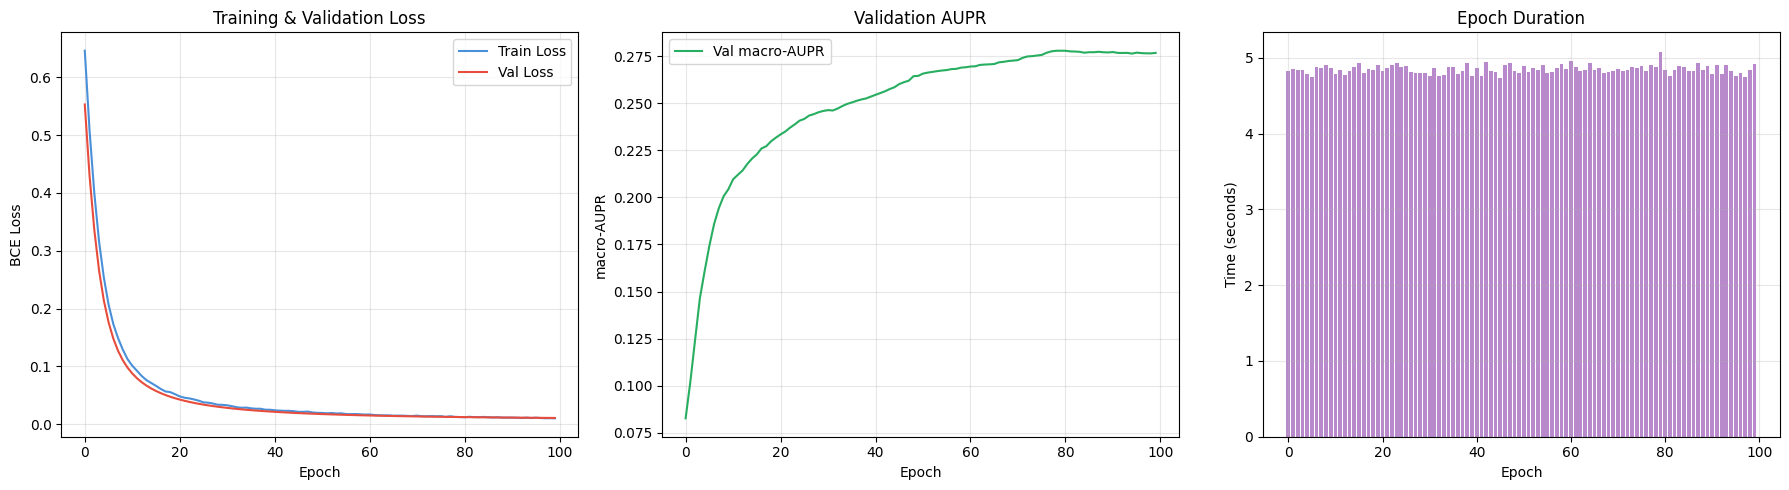

Training curves saved to /content/trained_models/training_curves.png


In [ ]:
# ============================================================
# Plot training curves
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(history["train_loss"], label="Train Loss", color="#4A90D9")
axes[0].plot(history["val_loss"], label="Val Loss", color="#E74C3C")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUPR curve
axes[1].plot(history["val_aupr"], label="Val macro-AUPR", color="#27AE60")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("macro-AUPR")
axes[1].set_title("Validation AUPR")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Epoch time
axes[2].bar(range(len(history["epoch_time"])), history["epoch_time"],
            color="#9B59B6", alpha=0.7)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Time (seconds)")
axes[2].set_title("Epoch Duration")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Training curves saved to {os.path.join(MODEL_DIR, 'training_curves.png')}")

# Compatability (same split) with GearNet, ESM-GearNet,  t5

Download GearNet, ESM-GearNet embeddings prepared before in previous notebook

In [ ]:
!gsutil -m ls gs://protein_shards

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://protein_shards/IA.txt
gs://protein_shards/Schake_model_v2.py
gs://protein_shards/Schake_trained_weights.pt
gs://protein_shards/VarBatchSampler.py
gs://protein_shards/esm_gearnet_all_pdbs_embeds.tar
gs://protein_shards/esm_gearnet_experimental_embeds.tar
gs://protein_shards/experimental_structures_valid_test.tar
gs://protein_shards/gearnet_embeds.zip
gs://protein_shards/gearnet_experimental_embeds.tar
gs://protein_shards/ggngo_dssp_features_short_train_and_real_val.tar
gs://protein_shards/ggngo_esm2_features_short_train_and_real_val.tar
gs://protein_shards/ggngo_eval_pack.tar
gs://protein_shards/ggngo_prottrans_features_short_train_and_real_val.tar
gs://protein_shards/ggngo_structure_data_features_short_train_and_real_val.tar
g

In [ ]:
!gsutil -m cp  -r gs://protein_shards/t5_prot_baseline_train_embeds.npy.zip .

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://protein_shards/t5_prot_baseline_train_embeds.npy.zip...
/ [1/1 files][625.8 MiB/625.8 MiB] 100% Done                                    
Operation completed over 1 objects/625.8 MiB.                                    


In [ ]:
!gsutil -m cp  -r gs://protein_shards/t5_prot_baseline_train_ids.npy.zip .

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://protein_shards/t5_prot_baseline_train_ids.npy.zip...
/ [1/1 files][942.9 KiB/942.9 KiB] 100% Done                                    
Operation completed over 1 objects/942.9 KiB.                                    


In [ ]:
!gsutil -m cp  -r gs://protein_shards/esm_gearnet_all_pdbs_embeds.tar .

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://protein_shards/esm_gearnet_all_pdbs_embeds.tar...
| [1/1 files][  5.5 GiB/  5.5 GiB] 100% Done  98.0 MiB/s ETA 00:00:00           
Operation completed over 1 objects/5.5 GiB.                                      


In [ ]:
!gsutil -m cp  -r gs://protein_shards/gearnet_embeds.zip .

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://protein_shards/gearnet_embeds.zip...
| [1/1 files][  2.7 GiB/  2.7 GiB] 100% Done  85.5 MiB/s ETA 00:00:00           
Operation completed over 1 objects/2.7 GiB.                                      


In [ ]:
!gsutil -m cp gs://protein_shards/short_train_and_real_val_ggngo_embeddings.tar .

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://protein_shards/short_train_and_real_val_ggngo_embeddings.tar...
- [1/1 files][349.7 MiB/349.7 MiB] 100% Done                                    
Operation completed over 1 objects/349.7 MiB.                                    


In [ ]:
!tar -xf esm_gearnet_all_pdbs_embeds.tar

In [ ]:
!tar -xf short_train_and_real_val_ggngo_embeddings.tar

In [ ]:
!unzip t5_prot_baseline_train_embeds.npy.zip
!unzip t5_prot_baseline_train_ids.npy.zip
!unzip gearnet_embeds.zip

Archive:  t5_prot_baseline_train_embeds.npy.zip
  inflating: train_embeds.npy        
Archive:  t5_prot_baseline_train_ids.npy.zip
  inflating: train_ids.npy           
Archive:  gearnet_embeds.zip
   creating: content/drive/MyDrive/go_finetune_runs/
  inflating: content/drive/MyDrive/go_finetune_runs/splits.csv  
  inflating: content/drive/MyDrive/go_finetune_runs/label_vocab.json  
  inflating: content/drive/MyDrive/go_finetune_runs/train_embeddings.pt  
  inflating: content/drive/MyDrive/go_finetune_runs/train_embeddings.npy  
  inflating: content/drive/MyDrive/go_finetune_runs/train_targets.npy  
  inflating: content/drive/MyDrive/go_finetune_runs/train_accessions.npy  
  inflating: content/drive/MyDrive/go_finetune_runs/train_pdb_files.npy  
  inflating: content/drive/MyDrive/go_finetune_runs/train_index.csv  
  inflating: content/drive/MyDrive/go_finetune_runs/valid_embeddings.pt  
  inflating: content/drive/MyDrive/go_finetune_runs/valid_embeddings.npy  
  inflating: content/dri

In [ ]:
!tar -xf esm_gearnet_all_pdbs_embeds.tar

In [ ]:
!cp -r ggngo_embeddings/ features/

In [ ]:
!mkdir -p {GEARNET_EMBEDS_DIR}
!cp -v content/drive/MyDrive/go_finetune_runs/* {GEARNET_EMBEDS_DIR}/
!ls -lh {GEARNET_EMBEDS_DIR} | head -50

'content/drive/MyDrive/go_finetune_runs/label_vocab.json' -> '/content/gearnet_embeds/label_vocab.json'
'content/drive/MyDrive/go_finetune_runs/splits.csv' -> '/content/gearnet_embeds/splits.csv'
'content/drive/MyDrive/go_finetune_runs/test_accessions.npy' -> '/content/gearnet_embeds/test_accessions.npy'
'content/drive/MyDrive/go_finetune_runs/test_embeddings.npy' -> '/content/gearnet_embeds/test_embeddings.npy'
'content/drive/MyDrive/go_finetune_runs/test_embeddings.pt' -> '/content/gearnet_embeds/test_embeddings.pt'
'content/drive/MyDrive/go_finetune_runs/test_index.csv' -> '/content/gearnet_embeds/test_index.csv'
'content/drive/MyDrive/go_finetune_runs/test_pdb_files.npy' -> '/content/gearnet_embeds/test_pdb_files.npy'
'content/drive/MyDrive/go_finetune_runs/test_targets.npy' -> '/content/gearnet_embeds/test_targets.npy'
'content/drive/MyDrive/go_finetune_runs/THIS DATA IS EMBEDDINGS GOT FROM GEARNET RAN ON G.csv' -> '/content/gearnet_embeds/THIS DATA IS EMBEDDINGS GOT FROM GEARNET 

## Do actual training

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task all \
  --split_mode all \
  --source t5 \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ids_npy /content/train_ids.npy \
  --embeds_npy /content/train_embeds.npy \
  --full_split_dir content/drive/MyDrive/go_finetune_runs \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/t5_same_split_bp \
  --epochs 100 \
  --batch_size 5120 \
  --head ggn

2026-05-02 12:00:27.293876: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 99627/99627 embeddings; missing=0
valid: matched 12369/12369 embeddings; missing=0

bp: selected 1100 labels
term
GO:0008150    63975
GO:0009987    43388
GO:0065007    29188
GO:0050789    27618
GO:0050794    23885
GO:0008152    22901
GO:0050896    21985
GO:0071704    21283
GO:0044237    19039
GO:0044238    18333
Name: count, dtype: int64

mf: selected 450 labels
term
GO:0003674    57690
GO:0005488    42139
GO:0005515    35319
GO:0003824    19077
GO:0097159     9606
GO:1901363     9489
GO:0003676     7636
GO:0016740     7365
GO:0016787     5890
GO:0140096     5352
Name: count, dtype: int64

cc: selected 300 labels
term
GO:0005575    680

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task all \
  --split_mode all \
  --source t5 \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ids_npy /content/train_ids.npy \
  --embeds_npy /content/train_embeds.npy \
  --full_split_dir content/drive/MyDrive/go_finetune_runs \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/t5_same_split_bp \
  --epochs 100 \
  --batch_size 5120 \
  --head mlp

2026-05-02 10:40:53.628259: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 99627/99627 embeddings; missing=0
valid: matched 12369/12369 embeddings; missing=0

bp: selected 1100 labels
term
GO:0008150    63975
GO:0009987    43388
GO:0065007    29188
GO:0050789    27618
GO:0050794    23885
GO:0008152    22901
GO:0050896    21985
GO:0071704    21283
GO:0044237    19039
GO:0044238    18333
Name: count, dtype: int64

mf: selected 450 labels
term
GO:0003674    57690
GO:0005488    42139
GO:0005515    35319
GO:0003824    19077
GO:0097159     9606
GO:1901363     9489
GO:0003676     7636
GO:0016740     7365
GO:0016787     5890
GO:0140096     5352
Name: count, dtype: int64

cc: selected 300 labels
term
GO:0005575    680

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task bp \
  --split_mode all \
  --source t5 \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ids_npy /content/train_ids.npy \
  --embeds_npy /content/train_embeds.npy \
  --full_split_dir content/drive/MyDrive/go_finetune_runs \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/t5_same_split_bp \
  --epochs 100 \
  --batch_size 5120 \
  --head mlp

2026-05-02 10:49:03.128820: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 99627/99627 embeddings; missing=0
valid: matched 12369/12369 embeddings; missing=0

bp: selected 1100 labels
term
GO:0008150    63975
GO:0009987    43388
GO:0065007    29188
GO:0050789    27618
GO:0050794    23885
GO:0008152    22901
GO:0050896    21985
GO:0071704    21283
GO:0044237    19039
GO:0044238    18333
Name: count, dtype: int64
direct labels used: 1957851
positive cells: 1957851
zero-label proteins: 35652 / 99627
empty label columns: 0 / 1100
direct labels used: 242950
positive cells: 242950
zero-label proteins: 4467 / 12369
empty label columns: 0 / 1100

Data
  x_train: (99627, 1024)
  y_train: (99627, 1100) positives: 19578

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task bp \
  --split_mode same \
  --source t5 \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ids_npy /content/train_ids.npy \
  --embeds_npy /content/train_embeds.npy \
  --full_split_dir content/drive/MyDrive/go_finetune_runs \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/t5_same_split_bp \
  --epochs 100 \
  --batch_size 5120 \
  --head mlp

2026-05-02 10:54:39.169286: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10947/10947 embeddings; missing=0
valid: matched 10987/10987 embeddings; missing=0

bp: selected 1100 labels
term
GO:0008150    7075
GO:0009987    4771
GO:0065007    3153
GO:0050789    2997
GO:0008152    2647
GO:0050794    2603
GO:0071704    2441
GO:0050896    2409
GO:0044237    2199
GO:0044238    2086
Name: count, dtype: int64
direct labels used: 212680
positive cells: 212680
zero-label proteins: 3872 / 10947
empty label columns: 0 / 1100
direct labels used: 212212
positive cells: 212212
zero-label proteins: 3934 / 10987
empty label columns: 0 / 1100

Data
  x_train: (10947, 1024)
  y_train: (10947, 1100) positives: 212680
  x_valid: 

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task bp \
  --split_mode same \
  --source t5 \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ids_npy /content/train_ids.npy \
  --embeds_npy /content/train_embeds.npy \
  --full_split_dir content/drive/MyDrive/go_finetune_runs \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/t5_same_split_bp \
  --epochs 200 \
  --batch_size 10240 \
  --head ggn

## t5 finetune on same small split

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task mf \
  --split_mode same \
  --source t5 \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task mf \
  --ids_npy /content/train_ids.npy \
  --embeds_npy /content/train_embeds.npy \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/t5_same_split_mf_plateau \
  --epochs 600 \
  --batch_size 10240 \
  --head ggn \
  --lr 8e-3 \
  --scheduler plateau \
  --patience 35 \
  --min_delta 1e-5 \
  --eval_every 0

2026-05-03 10:10:51.979922: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10947/10947 embeddings; missing=0
valid: matched 10987/10987 embeddings; missing=0

mf: selected 450 labels
term
GO:0003674    6444
GO:0005488    4711
GO:0005515    3929
GO:0003824    2208
GO:0097159    1076
GO:1901363    1061
GO:0016740     863
GO:0003676     840
GO:0016787     664
GO:0140096     604
Name: count, dtype: int64
direct labels used: 48856
positive cells: 48856
zero-label proteins: 4503 / 10947
empty label columns: 0 / 450
direct labels used: 47496
positive cells: 47496
zero-label proteins: 4604 / 10987
empty label columns: 0 / 450

Data
  x_train: (10947, 1024)
  y_train: (10947, 450) positives: 48856
  x_valid: (10987, 1

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task mf \
  --split_mode same \
  --source t5 \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task mf \
  --ids_npy /content/train_ids.npy \
  --embeds_npy /content/train_embeds.npy \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/t5_same_split_mf_onecycle \
  --epochs 200 \
  --batch_size 10240 \
  --head ggn \
  --lr 1e-2 \
  --scheduler onecycle \
  --patience 999 \
  --eval_every 0

2026-05-03 10:17:54.659698: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10947/10947 embeddings; missing=0
valid: matched 10987/10987 embeddings; missing=0

mf: selected 450 labels
term
GO:0003674    6444
GO:0005488    4711
GO:0005515    3929
GO:0003824    2208
GO:0097159    1076
GO:1901363    1061
GO:0016740     863
GO:0003676     840
GO:0016787     664
GO:0140096     604
Name: count, dtype: int64
direct labels used: 48856
positive cells: 48856
zero-label proteins: 4503 / 10947
empty label columns: 0 / 450
direct labels used: 47496
positive cells: 47496
zero-label proteins: 4604 / 10987
empty label columns: 0 / 450

Data
  x_train: (10947, 1024)
  y_train: (10947, 450) positives: 48856
  x_valid: (10987, 1

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task cc \
  --split_mode same \
  --source t5 \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task mf \
  --ids_npy /content/train_ids.npy \
  --embeds_npy /content/train_embeds.npy \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/t5_same_split_mf_plateau \
  --epochs 600 \
  --batch_size 10240 \
  --head ggn \
  --lr 8e-3 \
  --scheduler plateau \
  --patience 35 \
  --min_delta 1e-5 \
  --eval_every 0

2026-05-03 10:27:28.989140: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10947/10947 embeddings; missing=0
valid: matched 10987/10987 embeddings; missing=0

cc: selected 300 labels
term
GO:0005575    7468
GO:0110165    7355
GO:0005622    5754
GO:0043226    4966
GO:0043229    4745
GO:0043227    4608
GO:0005737    4448
GO:0043231    4332
GO:0005634    2239
GO:0016020    2186
Name: count, dtype: int64
direct labels used: 91828
positive cells: 91828
zero-label proteins: 3479 / 10947
empty label columns: 0 / 300
direct labels used: 89837
positive cells: 89837
zero-label proteins: 3581 / 10987
empty label columns: 0 / 300

Data
  x_train: (10947, 1024)
  y_train: (10947, 300) positives: 91828
  x_valid: (10987, 1

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task bp \
  --split_mode same \
  --source t5 \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task mf \
  --ids_npy /content/train_ids.npy \
  --embeds_npy /content/train_embeds.npy \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/t5_same_split_mf_plateau \
  --epochs 600 \
  --batch_size 10240 \
  --head ggn \
  --lr 8e-3 \
  --scheduler plateau \
  --patience 35 \
  --min_delta 1e-5 \
  --eval_every 0

2026-05-03 10:30:23.227907: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10947/10947 embeddings; missing=0
valid: matched 10987/10987 embeddings; missing=0

bp: selected 1100 labels
term
GO:0008150    7075
GO:0009987    4771
GO:0065007    3153
GO:0050789    2997
GO:0008152    2647
GO:0050794    2603
GO:0071704    2441
GO:0050896    2409
GO:0044237    2199
GO:0044238    2086
Name: count, dtype: int64
direct labels used: 212680
positive cells: 212680
zero-label proteins: 3872 / 10947
empty label columns: 0 / 1100
direct labels used: 212212
positive cells: 212212
zero-label proteins: 3934 / 10987
empty label columns: 0 / 1100

Data
  x_train: (10947, 1024)
  y_train: (10947, 1100) positives: 212680
  x_valid: 

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task all \
  --split_mode same \
  --source t5 \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task mf \
  --ids_npy /content/train_ids.npy \
  --embeds_npy /content/train_embeds.npy \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/t5_same_split_mf_plateau \
  --epochs 600 \
  --batch_size 10240 \
  --head ggn \
  --lr 8e-3 \
  --scheduler plateau \
  --patience 35 \
  --min_delta 1e-5 \
  --eval_every 0

2026-05-03 10:45:01.613704: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10947/10947 embeddings; missing=0
valid: matched 10987/10987 embeddings; missing=0

bp: selected 1100 labels
term
GO:0008150    7075
GO:0009987    4771
GO:0065007    3153
GO:0050789    2997
GO:0008152    2647
GO:0050794    2603
GO:0071704    2441
GO:0050896    2409
GO:0044237    2199
GO:0044238    2086
Name: count, dtype: int64

mf: selected 450 labels
term
GO:0003674    6444
GO:0005488    4711
GO:0005515    3929
GO:0003824    2208
GO:0097159    1076
GO:1901363    1061
GO:0016740     863
GO:0003676     840
GO:0016787     664
GO:0140096     604
Name: count, dtype: int64

cc: selected 300 labels
term
GO:0005575    7468
GO:0110165    7355

## gearnet finetune on same small split

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task all \
  --split_mode same \
  --source pt \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task bp \
  --embed_dir {GEARNET_EMBEDS_DIR} \
  --train_pt {GEARNET_EMBEDS_DIR}/train_embeddings.pt \
  --valid_pt {GEARNET_EMBEDS_DIR}/test_embeddings.pt \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/gearnet_same_split_all_plateau \
  --epochs 600 \
  --batch_size 10240 \
  --head mlp \
  --standardize \
  --lr 1e-3 \
  --scheduler plateau \
  --patience 35 \
  --min_delta 1e-5 \
  --eval_every 0

2026-05-03 15:33:24.578802: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10947/10947 embeddings; missing=0
valid: matched 10987/10987 embeddings; missing=0

Standardizing features using train mean/std...
  after standardization train mean/std: -1.363024471068286e-09 1.0000009536743164
  after standardization valid mean/std: 0.000592232565395534 1.0189194679260254

bp: selected 1100 labels
term
GO:0008150    7075
GO:0009987    4771
GO:0065007    3153
GO:0050789    2997
GO:0008152    2647
GO:0050794    2603
GO:0071704    2441
GO:0050896    2409
GO:0044237    2199
GO:0044238    2086
Name: count, dtype: int64

mf: selected 450 labels
term
GO:0003674    6444
GO:0005488    4711
GO:0005515    3929
GO:0003824    22

OK it would be fun if simple head still beats MLP for the whole dataset lets see

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task all \
  --split_mode all \
  --source pt \
  --full_split_dir {GEARNET_EMBEDS_DIR} \
  --embed_dir {GEARNET_EMBEDS_DIR} \
  --train_pt {GEARNET_EMBEDS_DIR}/train_embeddings.pt \
  --valid_pt {GEARNET_EMBEDS_DIR}/valid_embeddings.pt \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/gearnet_full_split_all_ggn_std_plateau \
  --epochs 600 \
  --batch_size 40240 \
  --head ggn \
  --standardize \
  --lr 8e-3 \
  --scheduler plateau \
  --patience 35 \
  --min_delta 1e-5 \
  --eval_every 0

2026-05-03 15:41:01.856539: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 99627/99627 embeddings; missing=0
valid: matched 12369/12369 embeddings; missing=0

Standardizing features using train mean/std...
  after standardization train mean/std: -5.213776077539478e-08 1.000012755393982
  after standardization valid mean/std: 0.0005547631881199777 0.986854612827301

bp: selected 1100 labels
term
GO:0008150    63975
GO:0009987    43388
GO:0065007    29188
GO:0050789    27618
GO:0050794    23885
GO:0008152    22901
GO:0050896    21985
GO:0071704    21283
GO:0044237    19039
GO:0044238    18333
Name: count, dtype: int64

mf: selected 450 labels
term
GO:0003674    57690
GO:0005488    42139
GO:0005515    35319
GO:0

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task all \
  --split_mode all \
  --source pt \
  --full_split_dir {GEARNET_EMBEDS_DIR} \
  --embed_dir {GEARNET_EMBEDS_DIR} \
  --train_pt {GEARNET_EMBEDS_DIR}/train_embeddings.pt \
  --valid_pt {GEARNET_EMBEDS_DIR}/valid_embeddings.pt \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/gearnet_full_split_all_mlp_std_plateau \
  --epochs 600 \
  --batch_size 40240 \
  --head mlp \
  --standardize \
  --lr 1e-3 \
  --scheduler plateau \
  --patience 35 \
  --min_delta 1e-5 \
  --eval_every 0

2026-05-03 15:53:59.270073: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 99627/99627 embeddings; missing=0
valid: matched 12369/12369 embeddings; missing=0

Standardizing features using train mean/std...
  after standardization train mean/std: -5.213776077539478e-08 1.000012755393982
  after standardization valid mean/std: 0.0005547631881199777 0.986854612827301

bp: selected 1100 labels
term
GO:0008150    63975
GO:0009987    43388
GO:0065007    29188
GO:0050789    27618
GO:0050794    23885
GO:0008152    22901
GO:0050896    21985
GO:0071704    21283
GO:0044237    19039
GO:0044238    18333
Name: count, dtype: int64

mf: selected 450 labels
term
GO:0003674    57690
GO:0005488    42139
GO:0005515    35319
GO:0

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task all \
  --split_mode same \
  --source pt \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task bp \
  --embed_dir {GEARNET_EMBEDS_DIR} \
  --train_pt {GEARNET_EMBEDS_DIR}/train_embeddings.pt \
  --valid_pt {GEARNET_EMBEDS_DIR}/test_embeddings.pt \
  --standardize \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/gearnet_same_split_all_plateau \
  --epochs 600 \
  --batch_size 10240 \
  --head ggn \
  --lr 8e-3 \
  --scheduler plateau \
  --patience 35 \
  --min_delta 1e-5 \
  --eval_every 0

2026-05-03 11:17:04.261044: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10947/10947 embeddings; missing=0
valid: matched 10987/10987 embeddings; missing=0

Standardizing features using train mean/std...
  after standardization train mean/std: -1.363024471068286e-09 1.0000009536743164
  after standardization valid mean/std: 0.000592232565395534 1.0189194679260254

bp: selected 1100 labels
term
GO:0008150    7075
GO:0009987    4771
GO:0065007    3153
GO:0050789    2997
GO:0008152    2647
GO:0050794    2603
GO:0071704    2441
GO:0050896    2409
GO:0044237    2199
GO:0044238    2086
Name: count, dtype: int64

mf: selected 450 labels
term
GO:0003674    6444
GO:0005488    4711
GO:0005515    3929
GO:0003824    22

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task all \
  --split_mode same \
  --source pt \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task bp \
  --embed_dir {GEARNET_EMBEDS_DIR} \
  --train_pt {GEARNET_EMBEDS_DIR}/train_embeddings.pt \
  --valid_pt {GEARNET_EMBEDS_DIR}/test_embeddings.pt \
  --standardize \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/gearnet_same_split_all_plateau \
  --epochs 600 \
  --batch_size 10240 \
  --head mlp \
  --lr 8e-3 \
  --scheduler plateau \
  --patience 35 \
  --min_delta 1e-5 \
  --eval_every 0

2026-05-03 11:30:47.257072: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10947/10947 embeddings; missing=0
valid: matched 10987/10987 embeddings; missing=0

Standardizing features using train mean/std...
  after standardization train mean/std: -1.363024471068286e-09 1.0000009536743164
  after standardization valid mean/std: 0.000592232565395534 1.0189194679260254

bp: selected 1100 labels
term
GO:0008150    7075
GO:0009987    4771
GO:0065007    3153
GO:0050789    2997
GO:0008152    2647
GO:0050794    2603
GO:0071704    2441
GO:0050896    2409
GO:0044237    2199
GO:0044238    2086
Name: count, dtype: int64

mf: selected 450 labels
term
GO:0003674    6444
GO:0005488    4711
GO:0005515    3929
GO:0003824    22

## esm-gearnet finetune on same small split

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task all \
  --split_mode same \
  --source pt \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task bp \
  --embed_dir /content/esm_gearnet_all_pdbs_embeds \
  --train_pt /content/esm_gearnet_all_pdbs_embeds/train_embeddings.pt \
  --valid_pt /content/esm_gearnet_all_pdbs_embeds/test_embeddings.pt \
  --standardize \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/esm_gearnet_same_split_all_plateau \
  --epochs 600 \
  --batch_size 10240 \
  --head ggn \
  --lr 8e-3 \
  --scheduler plateau \
  --patience 35 \
  --min_delta 1e-5 \
  --eval_every 0

2026-05-03 11:23:58.965009: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10344/10947 embeddings; missing=603
train: first missing IDs: ['Q3S2Y6', 'Q6P2H3', 'Q46812', 'Q7KSB5', 'A1Z9L0', 'Q8NC96', 'P54574', 'A1ZBF6', 'Q9UGJ0', 'Q8L7G9']
valid: matched 10457/10987 embeddings; missing=530
valid: first missing IDs: ['Q9NUL5', 'Q9UBS8', 'Q9VDD7', 'Q9Y1J3', 'A9LLI7', 'G5EF11', 'O35819', 'O93460', 'P32570', 'P42765']

Standardizing features using train mean/std...
  after standardization train mean/std: 1.3460600634118691e-08 1.000001072883606
  after standardization valid mean/std: 0.0006851606885902584 1.0087238550186157

bp: selected 1100 labels
term
GO:0008150    6679
GO:0009987    4513
GO:0065007    2952
GO:0

## GGN-GO Finetuning

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task bp \
  --source npz \
  --split_mode same \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task bp \
  --embed_dir {GGNGO_EMBEDS_DIR} \
  --npz_task bp \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/ggngo_bpemb_same_all_ggnhead \
  --epochs 200 \
  --batch_size 10240 \
  --head ggn

2026-05-02 11:31:45.861507: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10947/10947 embeddings; missing=0
valid: matched 10987/10987 embeddings; missing=0

bp: selected 1100 labels
term
GO:0008150    7075
GO:0009987    4771
GO:0065007    3153
GO:0050789    2997
GO:0008152    2647
GO:0050794    2603
GO:0071704    2441
GO:0050896    2409
GO:0044237    2199
GO:0044238    2086
Name: count, dtype: int64
direct labels used: 212680
positive cells: 212680
zero-label proteins: 3872 / 10947
empty label columns: 0 / 1100
direct labels used: 212212
positive cells: 212212
zero-label proteins: 3934 / 10987
empty label columns: 0 / 1100

Data
  x_train: (10947, 512)
  y_train: (10947, 1100) positives: 212680
  x_valid: (

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task cc \
  --source npz \
  --split_mode same \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task bp \
  --embed_dir {GGNGO_EMBEDS_DIR} \
  --npz_task bp \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/ggngo_bpemb_same_all_ggnhead \
  --epochs 200 \
  --batch_size 10240 \
  --head ggn

2026-05-02 11:48:51.504988: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10947/10947 embeddings; missing=0
valid: matched 10987/10987 embeddings; missing=0

cc: selected 300 labels
term
GO:0005575    7468
GO:0110165    7355
GO:0005622    5754
GO:0043226    4966
GO:0043229    4745
GO:0043227    4608
GO:0005737    4448
GO:0043231    4332
GO:0005634    2239
GO:0016020    2186
Name: count, dtype: int64
direct labels used: 91828
positive cells: 91828
zero-label proteins: 3479 / 10947
empty label columns: 0 / 300
direct labels used: 89837
positive cells: 89837
zero-label proteins: 3581 / 10987
empty label columns: 0 / 300

Data
  x_train: (10947, 512)
  y_train: (10947, 300) positives: 91828
  x_valid: (10987, 51

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task mf \
  --source npz \
  --split_mode same \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task bp \
  --embed_dir {GGNGO_EMBEDS_DIR} \
  --npz_task bp \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/ggngo_bpemb_same_all_ggnhead \
  --epochs 200 \
  --batch_size 10240 \
  --head ggn \
  --standardize

2026-05-03 11:42:08.050974: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10947/10947 embeddings; missing=0
valid: matched 10987/10987 embeddings; missing=0

Standardizing features using train mean/std...
  after standardization train mean/std: 1.5197905156583147e-08 1.0000003576278687
  after standardization valid mean/std: 0.0007075807661749423 1.0004380941390991

mf: selected 450 labels
term
GO:0003674    6444
GO:0005488    4711
GO:0005515    3929
GO:0003824    2208
GO:0097159    1076
GO:1901363    1061
GO:0016740     863
GO:0003676     840
GO:0016787     664
GO:0140096     604
Name: count, dtype: int64
direct labels used: 48856
positive cells: 48856
zero-label proteins: 4503 / 10947
empty label columns: 

In [ ]:
!python {ROOT_DIR}/scripts/train_mlp_clean_torch.py \
  --task mf \
  --source npz \
  --split_mode same \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task bp \
  --embed_dir {GGNGO_EMBEDS_DIR} \
  --npz_task bp \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/ggngo_bpemb_same_all_ggnhead \
  --epochs 200 \
  --batch_size 10240 \
  --head ggn

2026-05-02 11:50:30.365981: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda Tesla T4
train: matched 10947/10947 embeddings; missing=0
valid: matched 10987/10987 embeddings; missing=0

mf: selected 450 labels
term
GO:0003674    6444
GO:0005488    4711
GO:0005515    3929
GO:0003824    2208
GO:0097159    1076
GO:1901363    1061
GO:0016740     863
GO:0003676     840
GO:0016787     664
GO:0140096     604
Name: count, dtype: int64
direct labels used: 48856
positive cells: 48856
zero-label proteins: 4503 / 10947
empty label columns: 0 / 450
direct labels used: 47496
positive cells: 47496
zero-label proteins: 4604 / 10987
empty label columns: 0 / 450

Data
  x_train: (10947, 512)
  y_train: (10947, 450) positives: 48856
  x_valid: (10987, 51

## Evaluate naive baseline on our split

In [ ]:
!python {ROOT_DIR}/scripts/eval_naive_freq_cafa_small.py \
  --task all \
  --ref_dir {GGNGO_EMBEDS_DIR} \
  --ref_task bp \
  --train_terms_tsv {DATA_DIR}/train_terms.tsv \
  --go_obo {DATA_DIR}/go-basic.obo \
  --ia_txt {DATA_DIR}/IA.txt \
  --output_dir /content/naive_freq_small_all

2026-05-02 11:54:24.637674: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
bp: selected 1100 labels
term
GO:0008150    7075
GO:0009987    4771
GO:0065007    3153
GO:0050789    2997
GO:0008152    2647
GO:0050794    2603
GO:0071704    2441
GO:0050896    2409
GO:0044237    2199
GO:0044238    2086
Name: count, dtype: int64
mf: selected 450 labels
term
GO:0003674    6444
GO:0005488    4711
GO:0005515    3929
GO:0003824    2208
GO:0097159    1076
GO:1901363    1061
GO:0016740     863
GO:0003676     840
GO:0016787     664
GO:0140096     604
Name: count, dtype: int64
cc: selected 300 labels
term
GO:0005575    7468
GO:0110165    7355
GO:0005622    5754
GO:0043226    4966
GO:0043229    4745
GO:0043227    4608
GO:0005737    4448
GO:0043231    4332
GO:00056

## 8. Evaluation

Evaluate the trained model using CAFA competition metrics:
- **Fmax** — Maximum F-score over all thresholds
- **macro-AUPR** — Area under the precision-recall curve (macro-averaged)